In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set modern seaborn style
sns.set_theme(style="whitegrid", palette="Blues_r")


In [5]:
# Update the path as needed
df = pd.read_csv("/home/students/srtiwari/Project intro hnc/15april.csv")


Data exploration

In [2]:
# Load data
file_path = "/home/students/srtiwari/Project intro hnc/15april.csv"
df = pd.read_csv(file_path)

print(f"Dataset shape: {df.shape}")
print(f"Number of features: {df.shape[1]}")
print(f"Number of samples: {df.shape[0]}")
print("\nData Types:\n", df.dtypes)
print("\nFirst five rows:\n", df.head())


Dataset shape: (209851, 16)
Number of features: 16
Number of samples: 209851

Data Types:
 Age recode with <1 year olds                       object
Sex                                                object
Site recode ICD-O-3 2023 Revision Expanded         object
Grade Pathological (2018+)                         object
Derived AJCC T, 7th ed (2010-2015)                 object
Derived AJCC N, 7th ed (2010-2015)                 object
Derived AJCC M, 7th ed (2010-2015)                 object
7th Edition Stage Group Recode (2016-2017)         object
Derived SEER Cmb Stg Grp (2016-2017)               object
RX Summ--Systemic/Sur Seq (2007+)                  object
RX Summ--Surg/Rad Seq                              object
SEER cause-specific death classification           object
Survival months                                    object
Time from diagnosis to treatment in days recode    object
COD to site recode ICD-O-3 2023 Revision           object
Vital status recode (study cutoff used)

Dataset shape: (209851, 16)
Number of features: 16
Number of samples: 209851

Data Types:
 Age recode with <1 year olds                       object
Sex                                                object
Site recode ICD-O-3 2023 Revision Expanded         object
Grade Pathological (2018+)                         object
Derived AJCC T, 7th ed (2010-2015)                 object
Derived AJCC N, 7th ed (2010-2015)                 object
Derived AJCC M, 7th ed (2010-2015)                 object
7th Edition Stage Group Recode (2016-2017)         object
Derived SEER Cmb Stg Grp (2016-2017)               object
RX Summ--Systemic/Sur Seq (2007+)                  object
RX Summ--Surg/Rad Seq                              object
SEER cause-specific death classification           object
Survival months                                    object
Time from diagnosis to treatment in days recode    object
COD to site recode ICD-O-3 2023 Revision           object
Vital status recode (study cutoff used)

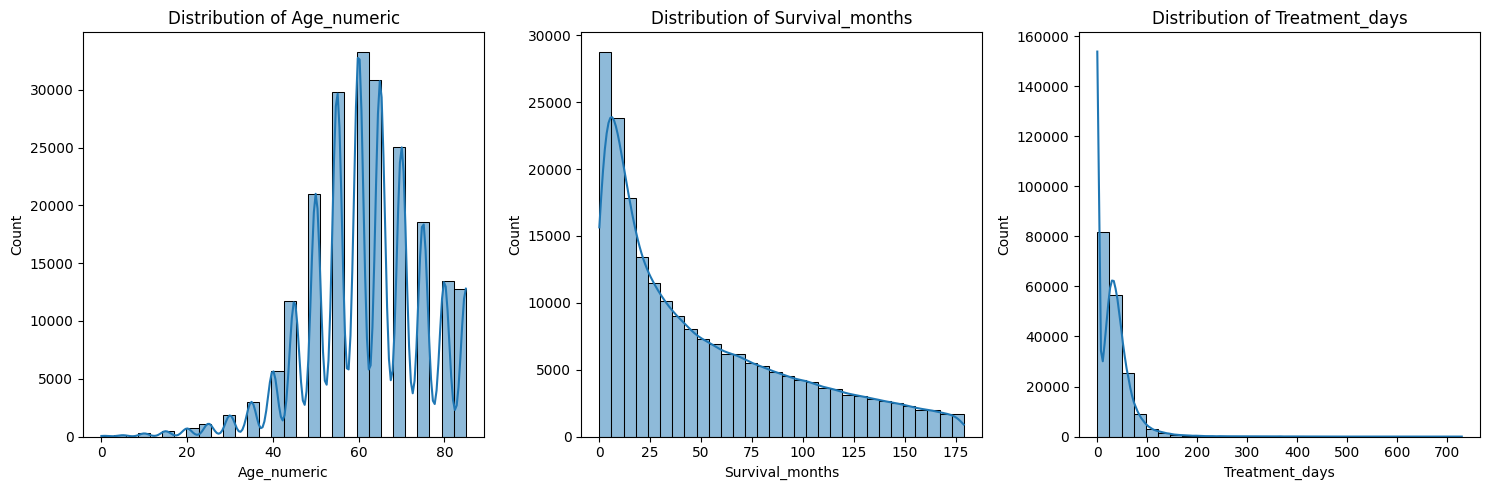

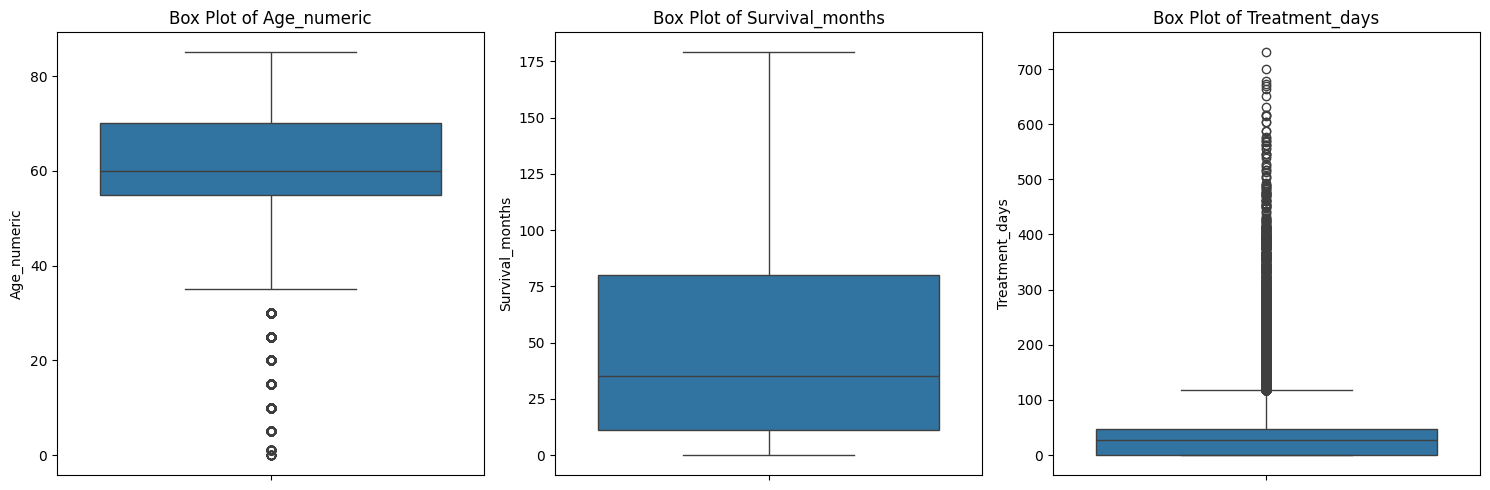

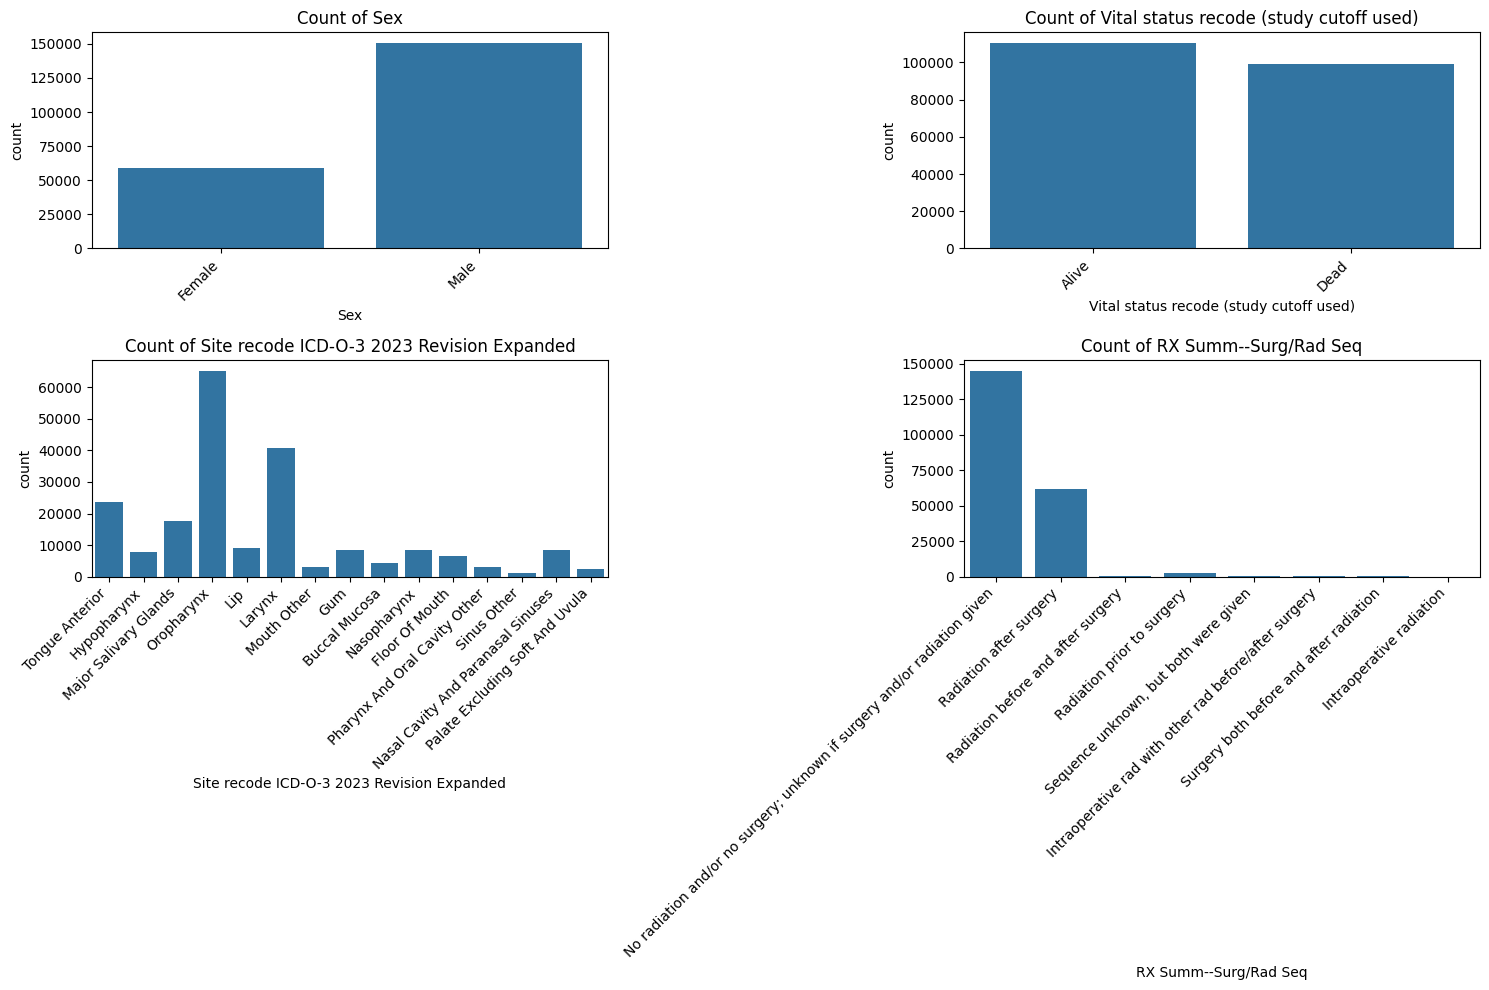

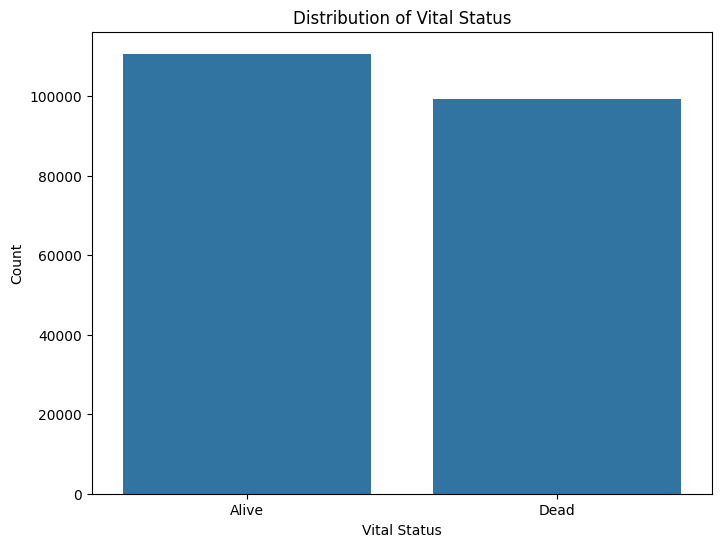

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load data
file_path = "/home/students/srtiwari/Project intro hnc/15april.csv"
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print("Error: File not found. Please check the file path.")
    exit()

# Step 2: Display basic information
print(f"Dataset shape: {df.shape}")
print(f"Number of features: {df.shape[1]}")
print(f"Number of samples: {df.shape[0]}")
print("\nData Types:\n", df.dtypes)
print("\nFirst five rows:\n", df.head())

# Step 3: Preprocess numerical columns
# Convert 'Survival months' to numeric
df['Survival_months'] = pd.to_numeric(df['Survival months'], errors='coerce')

# Extract numerical age from 'Age recode with <1 year olds' (e.g., "60-64 years" -> 62)
df['Age_numeric'] = df['Age recode with <1 year olds'].str.extract(r'(\d+)-?\d*').astype(float)
# For single ages (e.g., "<1 year"), set to 0 or handle separately
df['Age_numeric'] = df['Age_numeric'].fillna(0)

# Convert 'Time from diagnosis to treatment in days recode' to numeric
df['Treatment_days'] = pd.to_numeric(df['Time from diagnosis to treatment in days recode'], errors='coerce')

# Step 4: Summary statistics for numerical columns
numerical_cols = ['Age_numeric', 'Survival_months', 'Treatment_days']
print("\nSummary Statistics for Numerical Columns:")
print(df[numerical_cols].describe())

# Step 5: Visualizations for raw data
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Histograms for numerical columns
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col].dropna(), bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Box plots for numerical columns to identify outliers
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col].dropna())
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()

# Bar plots for categorical columns (limit to first 4 for brevity)
selected_categorical = ['Sex', 'Vital status recode (study cutoff used)', 
                       'Site recode ICD-O-3 2023 Revision Expanded', 'RX Summ--Surg/Rad Seq']
plt.figure(figsize=(15, 10))
for i, col in enumerate(selected_categorical, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=col, data=df)
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Count plot for target variable
plt.figure(figsize=(8, 6))
sns.countplot(x='Vital status recode (study cutoff used)', data=df)
plt.title('Distribution of Vital Status')
plt.xlabel('Vital Status')
plt.ylabel('Count')
plt.show()

What problem is best to solve ?

Data loaded successfully!

Cleaning survival months data:
 - Converted 1387 non-numeric values to NaN
 - Imputed 1387 missing values with median: 35.0 months



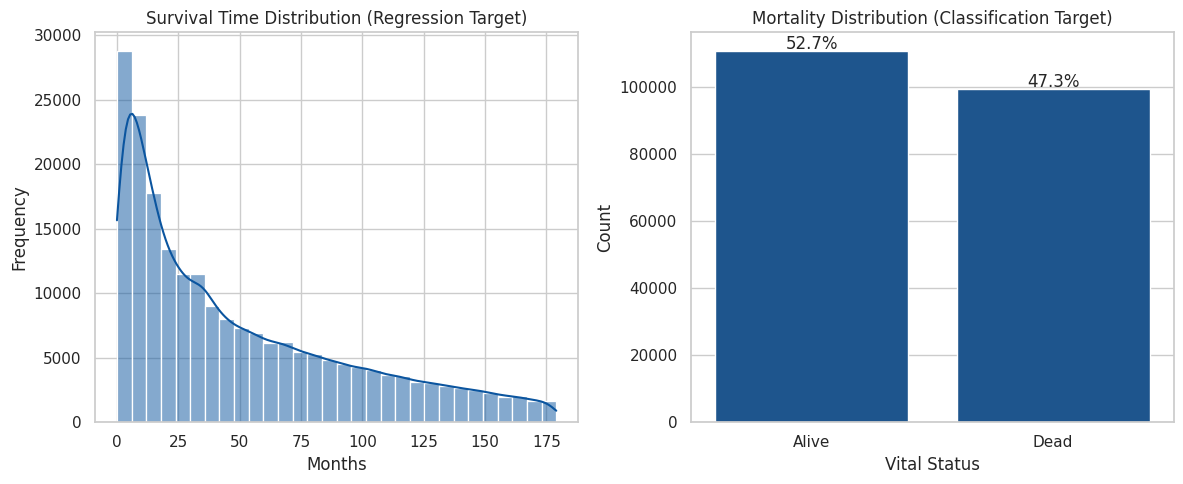


Classification target analysis:
Vital status recode (study cutoff used)
Alive    0.527141
Dead     0.472859
Name: proportion, dtype: float64

Regression target analysis:
count    209851.000000
mean         50.258984
std          46.565572
min           0.000000
25%          11.000000
50%          35.000000
75%          79.000000
max         179.000000
Name: Survival_months_imputed, dtype: float64

Recommended Approach: PRIORITIZE CLASSIFICATION
Reasons:
- Mortality prediction is more clinically actionable
- Survival time data requires significant cleaning/imputation


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set modern plotting style
sns.set_theme(style="whitegrid", palette="Blues_r")

def load_and_analyze_data(file_path):
    try:
        # Load dataset with error handling
        df = pd.read_csv(file_path)
        print("Data loaded successfully!\n")
        
        # Clean Survival Months
        if 'Survival months' in df.columns:
            print("Cleaning survival months data:")
            df['Survival_months_clean'] = pd.to_numeric(
                df['Survival months'], 
                errors='coerce'
            )
            
            # Calculate missing values
            missing_count = df['Survival_months_clean'].isnull().sum()
            print(f" - Converted {missing_count} non-numeric values to NaN")
            
            # Impute missing values
            median_survival = df['Survival_months_clean'].median()
            df['Survival_months_imputed'] = df['Survival_months_clean'].fillna(median_survival)
            print(f" - Imputed {missing_count} missing values with median: {median_survival:.1f} months\n")
        
        # Visualize both potential targets
        plt.figure(figsize=(12, 5))
        
        # Survival months distribution (if available)
        if 'Survival_months_imputed' in df.columns:
            plt.subplot(1, 2, 1)
            sns.histplot(df['Survival_months_imputed'], bins=30, kde=True)
            plt.title('Survival Time Distribution (Regression Target)')
            plt.xlabel('Months')
            plt.ylabel('Frequency')
        
        # Vital status distribution (if available)
        if 'Vital status recode (study cutoff used)' in df.columns:
            plt.subplot(1, 2, 2)
            vital_counts = df['Vital status recode (study cutoff used)'].value_counts()
            sns.barplot(x=vital_counts.index, y=vital_counts.values)
            plt.title('Mortality Distribution (Classification Target)')
            plt.xlabel('Vital Status')
            plt.ylabel('Count')
            
            # Add percentage labels
            total = len(df)
            for i, count in enumerate(vital_counts):
                plt.text(i, count+500, f'{count/total:.1%}', ha='center')
        
        plt.tight_layout()
        plt.show()
        
        # Problem type determination
        problem_type = None
        if 'Vital status recode (study cutoff used)' in df.columns:
            print("\nClassification target analysis:")
            print(df['Vital status recode (study cutoff used)'].value_counts(normalize=True))
            problem_type = 'classification'
        
        if 'Survival_months_imputed' in df.columns:
            print("\nRegression target analysis:")
            print(df['Survival_months_imputed'].describe())
            problem_type = 'regression' if problem_type is None else 'both'
        
        # Final recommendation
        print("\n" + "="*50)
        if problem_type == 'classification':
            print("Recommended Approach: CLASSIFICATION (Mortality Prediction)")
            print("Reason: Clear binary target variable with complete data")
        elif problem_type == 'regression':
            print("Recommended Approach: REGRESSION (Survival Time Prediction)")
            print("Reason: Continuous target variable available")
        else:
            print("Recommended Approach: PRIORITIZE CLASSIFICATION")
            print("Reasons:")
            print("- Mortality prediction is more clinically actionable")
            print("- Survival time data requires significant cleaning/imputation")
        
        return df
        
    except FileNotFoundError:
        print(f"Error: File not found at '{file_path}'")
        print("Please verify:")
        print("1. File exists at specified path")
        print("2. Path is case-sensitive")
        print("3. No typos in filename")
    except Exception as e:
        print(f"Unexpected error: {str(e)}")

# Run the analysis (update path if needed)
file_path = "/home/students/srtiwari/Project intro hnc/15april.csv"
data = load_and_analyze_data(file_path)


In [7]:
import pandas as pd
import numpy as np

# Load data
file_path = "/home/students/srtiwari/Project intro hnc/15april.csv"
df = pd.read_csv(file_path)

# Basic checks
print(f"Dataset shape: {df.shape}")
print(f"Number of features: {df.shape[1]}")
print(f"Number of samples: {df.shape[0]}")
print("\nData Types:\n", df.dtypes)
print("\nFirst five rows:\n", df.head())
print("\nMissing Values:\n", df.isnull().sum())
print("\nClass Distribution for 'Vital status recode (study cutoff used)':\n", 
      df['Vital status recode (study cutoff used)'].value_counts(normalize=True))

Dataset shape: (209851, 16)
Number of features: 16
Number of samples: 209851

Data Types:
 Age recode with <1 year olds                       object
Sex                                                object
Site recode ICD-O-3 2023 Revision Expanded         object
Grade Pathological (2018+)                         object
Derived AJCC T, 7th ed (2010-2015)                 object
Derived AJCC N, 7th ed (2010-2015)                 object
Derived AJCC M, 7th ed (2010-2015)                 object
7th Edition Stage Group Recode (2016-2017)         object
Derived SEER Cmb Stg Grp (2016-2017)               object
RX Summ--Systemic/Sur Seq (2007+)                  object
RX Summ--Surg/Rad Seq                              object
SEER cause-specific death classification           object
Survival months                                    object
Time from diagnosis to treatment in days recode    object
COD to site recode ICD-O-3 2023 Revision           object
Vital status recode (study cutoff used)

No numerical columns found for normality testing.

Skipped normality checks - no numerical columns found.

Target Distribution Analysis:


/tmp/ipykernel_1580274/3912749164.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette='viridis')


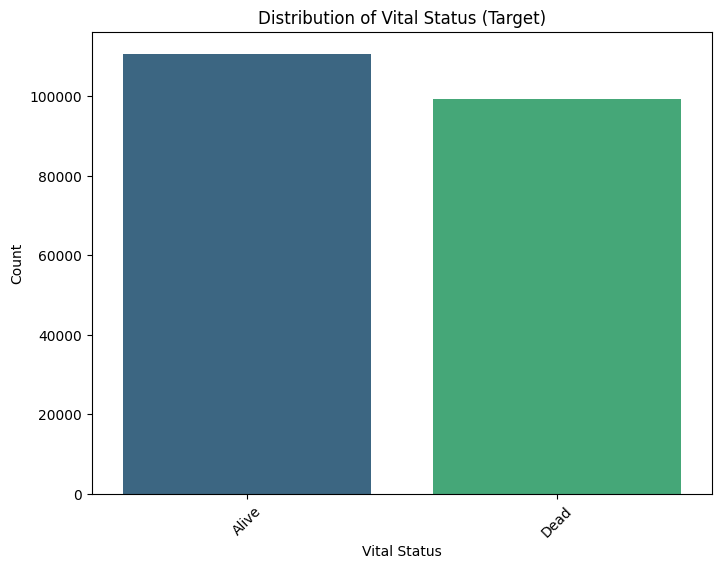


Feature-Target Visualizations:


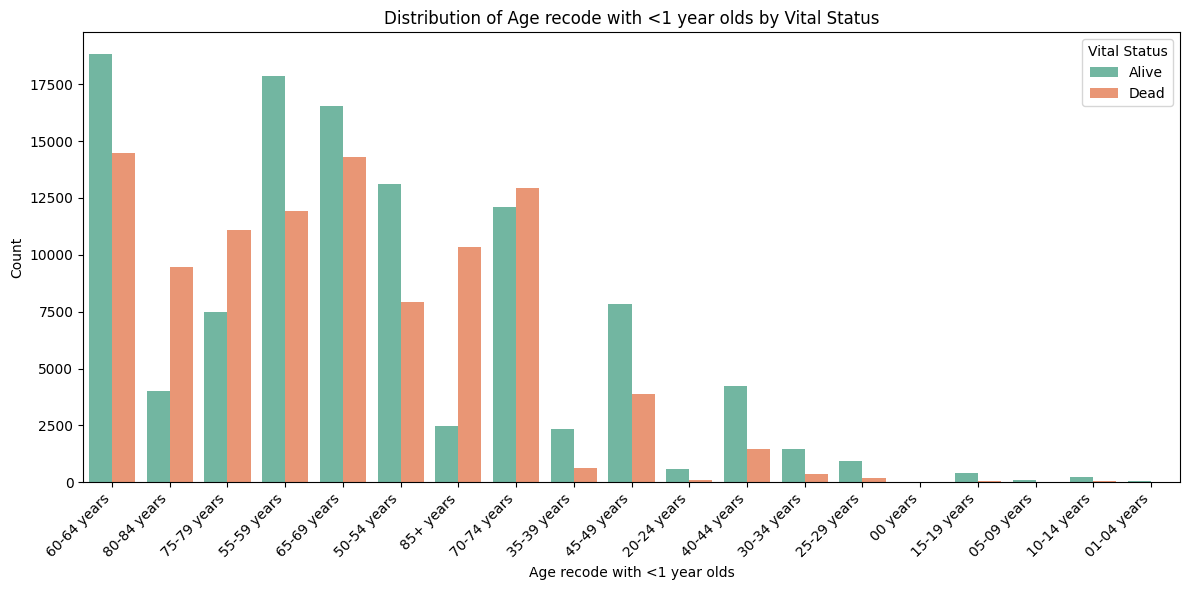

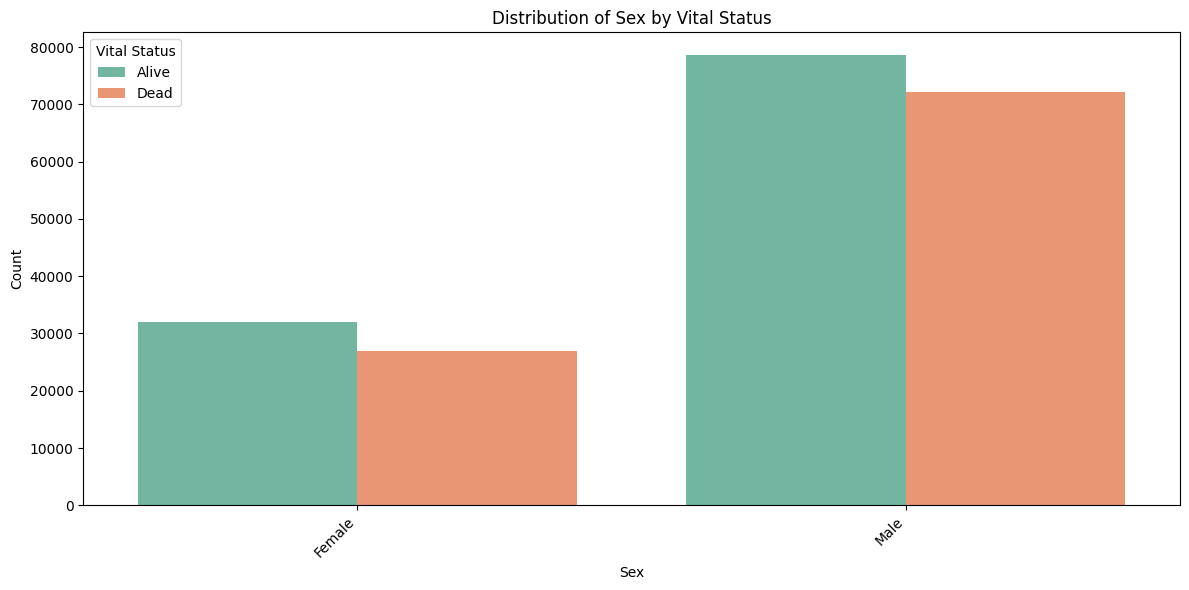

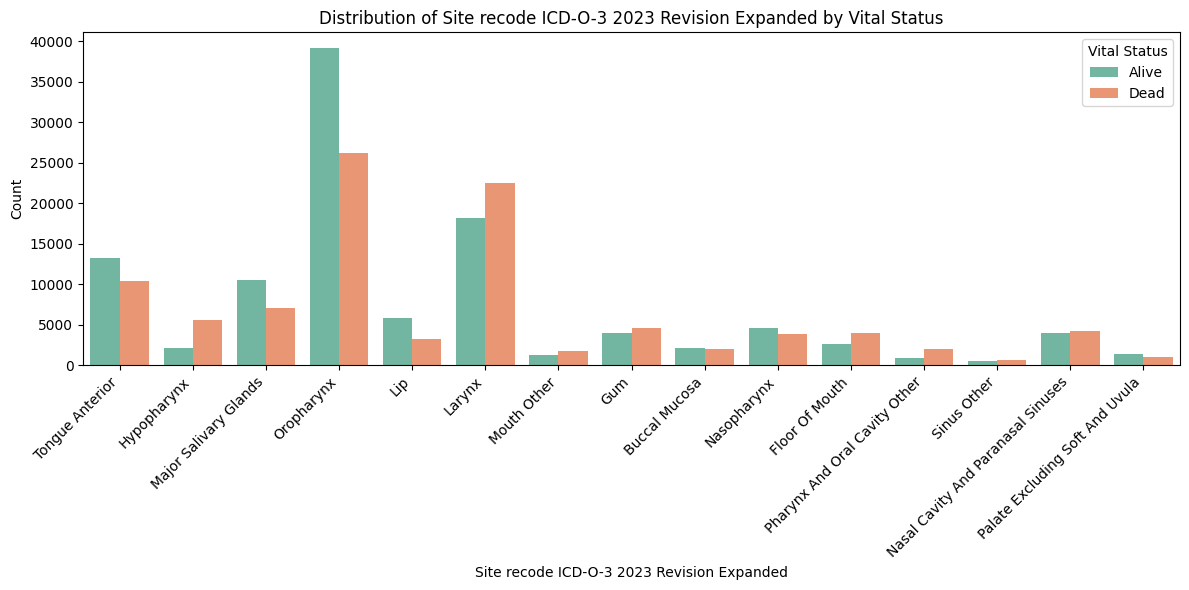

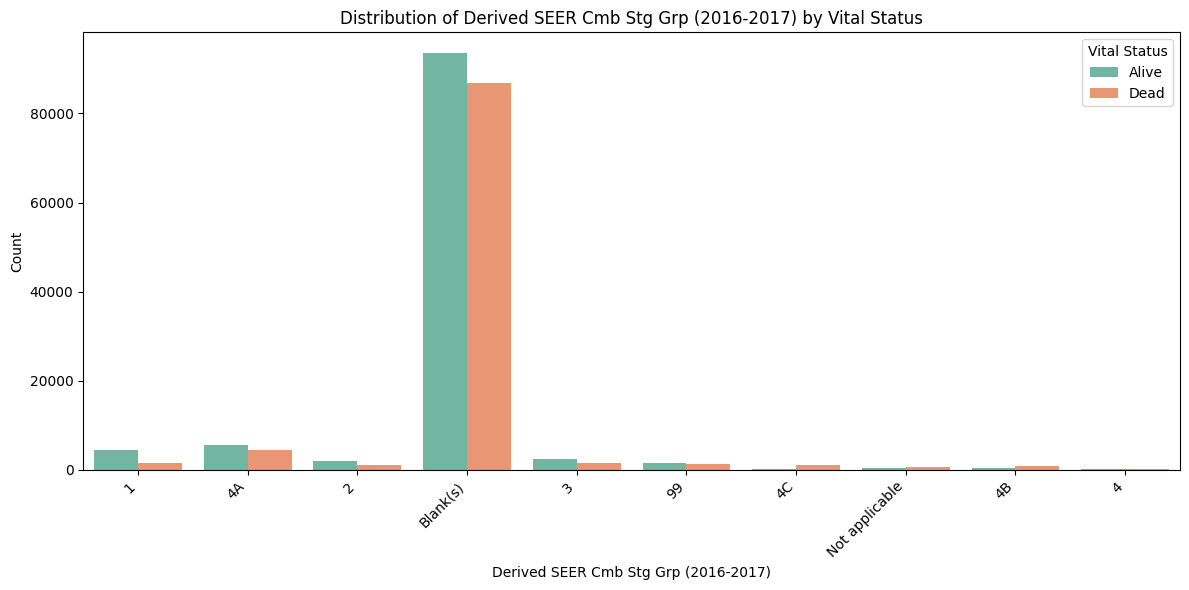

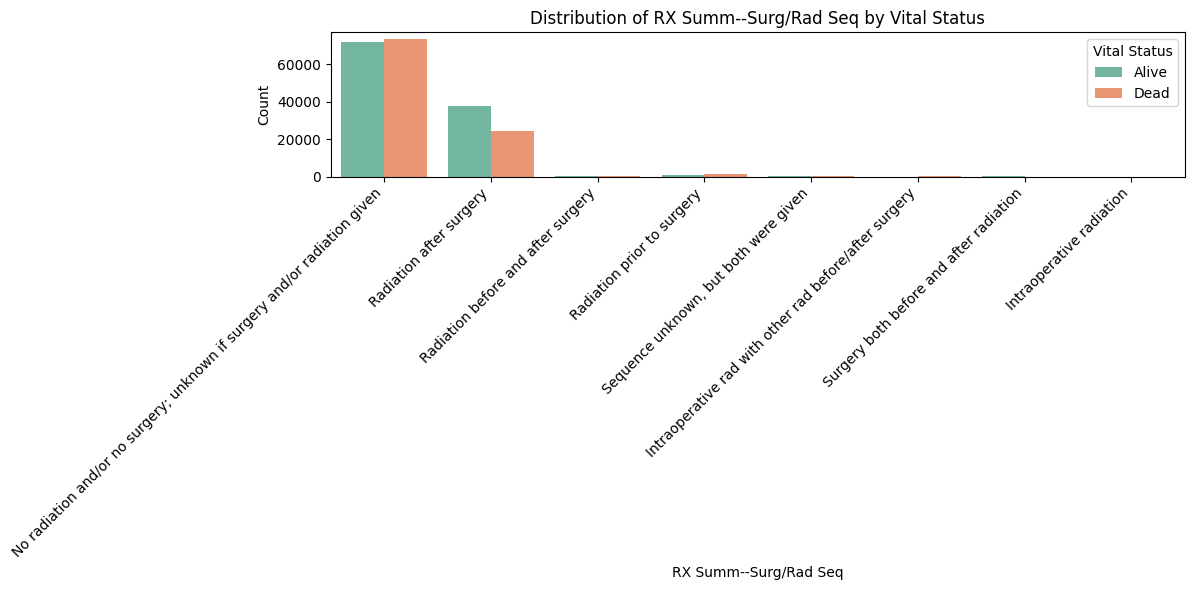


Feature Characteristics:
Unique Values per Feature:
                                                  Unique Values
Time from diagnosis to treatment in days recode            469
Survival months                                            181
COD to site recode ICD-O-3 2023 Revision                   106
Age recode with <1 year olds                                19
Site recode ICD-O-3 2023 Revision Expanded                  15
Derived AJCC N, 7th ed (2010-2015)                          13
Derived AJCC T, 7th ed (2010-2015)                          13
Grade Pathological (2018+)                                  11
Derived SEER Cmb Stg Grp (2016-2017)                        10
7th Edition Stage Group Recode (2016-2017)                   9
RX Summ--Systemic/Sur Seq (2007+)                            8
RX Summ--Surg/Rad Seq                                        8
Derived AJCC M, 7th ed (2010-2015)                           3
SEER cause-specific death classification                     3
S

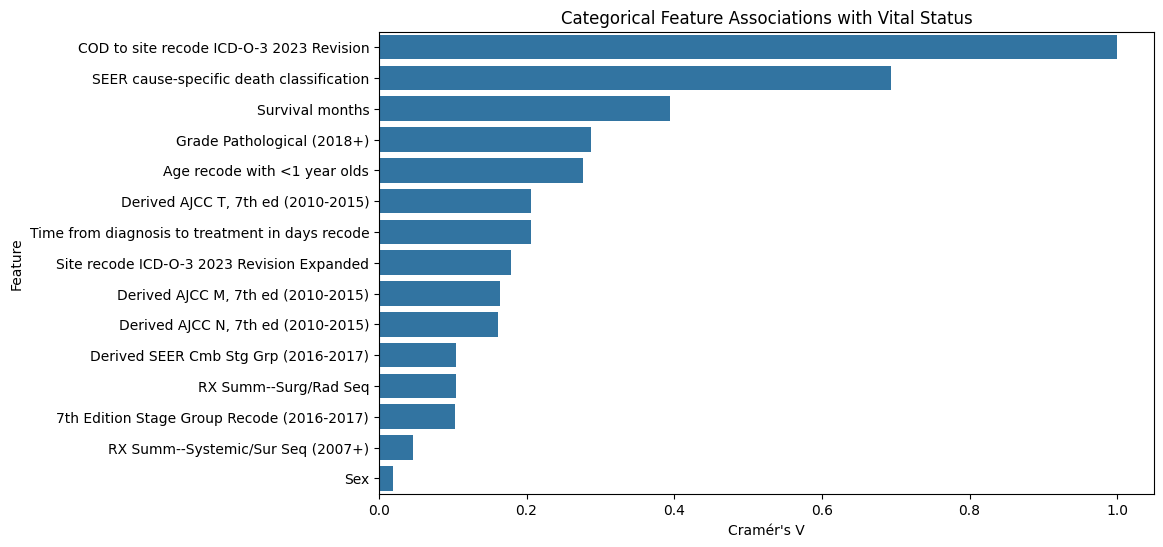


Top Correlated Features:
                                            Feature  Cramér's V
14         COD to site recode ICD-O-3 2023 Revision    0.999752
11         SEER cause-specific death classification    0.694080
12                                  Survival months    0.394517
3                        Grade Pathological (2018+)    0.286832
0                      Age recode with <1 year olds    0.276341
4                Derived AJCC T, 7th ed (2010-2015)    0.206586
13  Time from diagnosis to treatment in days recode    0.206341
2        Site recode ICD-O-3 2023 Revision Expanded    0.178652
6                Derived AJCC M, 7th ed (2010-2015)    0.164480
5                Derived AJCC N, 7th ed (2010-2015)    0.161849


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, chi2_contingency

# Ensure reproducibility
np.random.seed(42)

# Load data
file_path = "/home/students/srtiwari/Project intro hnc/15april.csv"
df = pd.read_csv(file_path)

# 1. Normality Check for Numerical Features
def check_normality(df):
    """Perform Shapiro-Wilk normality test for numerical columns."""
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    if not num_cols:
        print("No numerical columns found for normality testing.")
        return pd.DataFrame()

    normality_results = {}
    
    for col in num_cols:
        data = df[col].dropna()
        result = {
            'statistic': np.nan,
            'p_value': np.nan,
            'note': 'No test performed',
            'sample_size': len(data)
        }
        
        if len(data) > 3:
            try:
                stat, p = shapiro(data)
                result.update({
                    'statistic': stat,
                    'p_value': p,
                    'note': 'Test performed'
                })
            except Exception as e:
                result['note'] = f"Test failed: {str(e)}"
        else:
            result['note'] = "Insufficient data (n ≤ 3)"
        
        normality_results[col] = result
    
    normality_df = pd.DataFrame.from_dict(normality_results, orient='index')
    
    # Safely add normality conclusion
    if 'p_value' in normality_df.columns:
        normality_df['normality'] = normality_df['p_value'].apply(
            lambda x: x > 0.05 if pd.notnull(x) else None
        )
    
    return normality_df

# Execute normality checks
normality_df = check_normality(df)
if not normality_df.empty:
    print("\nShapiro-Wilk Normality Test Results:")
    print(normality_df[['statistic', 'p_value', 'normality', 'note']])
else:
    print("\nSkipped normality checks - no numerical columns found.")

# 2. Categorical Feature Analysis
target_col = 'Vital status recode (study cutoff used)'
cat_cols = [col for col in df.columns if col != target_col]

# Target Distribution
print("\nTarget Distribution Analysis:")
plt.figure(figsize=(8, 6))
sns.countplot(x=target_col, data=df, palette='viridis')
plt.title("Distribution of Vital Status (Target)")
plt.xlabel("Vital Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.savefig('target_distribution.png')
plt.show()

# Feature-Target Relationships
key_features = [
    'Age recode with <1 year olds',
    'Sex',
    'Site recode ICD-O-3 2023 Revision Expanded',
    'Derived SEER Cmb Stg Grp (2016-2017)',
    'RX Summ--Surg/Rad Seq'
]

print("\nFeature-Target Visualizations:")
for col in key_features:
    plt.figure(figsize=(12, 6))
    sns.countplot(x=col, hue=target_col, data=df, palette='Set2')
    plt.title(f"Distribution of {col} by Vital Status")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha='right')
    plt.legend(title="Vital Status")
    plt.tight_layout()
    plt.savefig(f'distribution_{col.replace("/", "_").replace(" ", "_")}.png')
    plt.show()

# 3. Feature Characteristics Analysis
print("\nFeature Characteristics:")
unique_counts_df = pd.DataFrame(
    {col: df[col].nunique() for col in cat_cols},
    index=['Unique Values']
).T.sort_values('Unique Values', ascending=False)
print("Unique Values per Feature:\n", unique_counts_df)

# 4. Rare Category Analysis
print("\nRare Category Identification (<1% frequency):")
for col in cat_cols:
    value_counts = df[col].value_counts(normalize=True)
    rare_categories = value_counts[value_counts < 0.01].index.tolist()
    if rare_categories:
        print(f"{col}: {len(rare_categories)} rare categories")

# 5. Missing Value Analysis
missing_summary = df.isnull().sum()
print("\nMissing Values Summary:\n", missing_summary[missing_summary > 0])

# 6. Cramér's V Correlation Analysis
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

print("\nCramér's V Correlation Analysis:")
cramers_v_scores = {col: cramers_v(df[col], df[target_col]) for col in cat_cols}
cramers_v_df = pd.DataFrame(cramers_v_scores.items(), columns=['Feature', 'Cramér\'s V'])
cramers_v_df = cramers_v_df.sort_values('Cramér\'s V', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Cramér\'s V', y='Feature', data=cramers_v_df)
plt.title("Categorical Feature Associations with Vital Status")
plt.savefig('cramers_v.png')
plt.show()

print("\nTop Correlated Features:")
print(cramers_v_df.head(10))


In [ ]:
Data cleaning using mode(again plot)

In [2]:
import pandas as pd
import numpy as np

# Load the dataset
file_path = "15april.csv"  # Update this path to your actual file location
df = pd.read_csv(file_path)

# Define target and categorical features
target_col = 'Vital status recode (study cutoff used)'
cat_cols = [
    'Age recode with <1 year olds', 'Sex', 'Site recode ICD-O-3 2023 Revision Expanded',
    'Grade Pathological (2018+)', 'Derived AJCC T, 7th ed (2010-2015)',
    'Derived AJCC N, 7th ed (2010-2015)', 'Derived AJCC M, 7th ed (2010-2015)',
    '7th Edition Stage Group Recode (2016-2017)', 'Derived SEER Cmb Stg Grp (2016-2017)',
    'RX Summ--Systemic/Sur Seq (2007+)', 'RX Summ--Surg/Rad Seq',
    'SEER cause-specific death classification', 'Survival months',
    'Time from diagnosis to treatment in days recode', 'COD to site recode ICD-O-3 2023 Revision'
]

# Step 1: Handle Missing Values with Mode Imputation
print("Missing Values Before Imputation:\n", df[cat_cols].isnull().sum())
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode().iloc[0]  # Get the most frequent value
        df[col].fillna(mode_value, inplace=True)  # Fill missing values with mode
print("\nMissing Values After Mode Imputation:\n", df[cat_cols].isnull().sum())

# Step 2: Explicitly categorize 'Blank(s)' in TNM staging, Grade Pathological, and Stage Group Recode columns as 'Other'
cols_to_modify = [
    'Derived AJCC T, 7th ed (2010-2015)', 'Derived AJCC N, 7th ed (2010-2015)',
    'Derived AJCC M, 7th ed (2010-2015)', 'Grade Pathological (2018+)',
    '7th Edition Stage Group Recode (2016-2017)'
]
for col in cols_to_modify:
    df[col] = df[col].replace('Blank(s)', 'Other')

# Step 3: Remove Duplicates
initial_shape = df.shape
df = df.drop_duplicates()
print(f"\nRemoved {initial_shape[0] - df.shape[0]} duplicate rows")
print(f"New dataset shape: {df.shape}")

# Step 4: Handle Rare Categories - Group into 'Other' if frequency <1%
for col in cat_cols:
    value_counts = df[col].value_counts(normalize=True)
    rare_categories = value_counts[value_counts < 0.01].index
    if rare_categories.size > 0:
        df[col] = df[col].apply(lambda x: 'Other' if x in rare_categories else x)
        print(f"\nGrouped rare categories in '{col}' into 'Other'")
        print(f"Updated unique values:\n", df[col].value_counts())

# Ensure target column is not modified
df[target_col] = df[target_col].astype(str)  # Ensure target remains categorical

# Save the cleaned dataset
df.to_csv("15april_cleaned.csv", index=False)
print("\nData cleaning complete. Cleaned dataset saved as '15april_cleaned.csv'.")

Missing Values Before Imputation:
 Age recode with <1 year olds                          0
Sex                                                   0
Site recode ICD-O-3 2023 Revision Expanded            0
Grade Pathological (2018+)                            0
Derived AJCC T, 7th ed (2010-2015)                 2657
Derived AJCC N, 7th ed (2010-2015)                 2620
Derived AJCC M, 7th ed (2010-2015)                 2620
7th Edition Stage Group Recode (2016-2017)         1074
Derived SEER Cmb Stg Grp (2016-2017)                  0
RX Summ--Systemic/Sur Seq (2007+)                     0
RX Summ--Surg/Rad Seq                                 0
SEER cause-specific death classification              0
Survival months                                       0
Time from diagnosis to treatment in days recode       0
COD to site recode ICD-O-3 2023 Revision              0
dtype: int64


/tmp/ipykernel_2928724/3396348958.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_value, inplace=True)  # Fill missing values with mode



Missing Values After Mode Imputation:
 Age recode with <1 year olds                       0
Sex                                                0
Site recode ICD-O-3 2023 Revision Expanded         0
Grade Pathological (2018+)                         0
Derived AJCC T, 7th ed (2010-2015)                 0
Derived AJCC N, 7th ed (2010-2015)                 0
Derived AJCC M, 7th ed (2010-2015)                 0
7th Edition Stage Group Recode (2016-2017)         0
Derived SEER Cmb Stg Grp (2016-2017)               0
RX Summ--Systemic/Sur Seq (2007+)                  0
RX Summ--Surg/Rad Seq                              0
SEER cause-specific death classification           0
Survival months                                    0
Time from diagnosis to treatment in days recode    0
COD to site recode ICD-O-3 2023 Revision           0
dtype: int64

Removed 10911 duplicate rows
New dataset shape: (198940, 16)

Grouped rare categories in 'Age recode with <1 year olds' into 'Other'
Updated unique val

In [10]:
import pandas as pd
import numpy as np

# Load the dataset
file_path = "15april.csv"  # Update this path to your actual file location
df = pd.read_csv(file_path)

# Define target variable
target_col = 'Vital status recode (study cutoff used)'

# Define known categorical columns (based on previous context)
cat_cols = [
    'Age recode with <1 year olds', 'Sex', 'Site recode ICD-O-3 2023 Revision Expanded',
    'Grade Pathological (2018+)', 'Derived AJCC T, 7th ed (2010-2015)',
    'Derived AJCC N, 7th ed (2010-2015)', 'Derived AJCC M, 7th ed (2010-2015)',
    '7th Edition Stage Group Recode (2016-2017)', 'Derived SEER Cmb Stg Grp (2016-2017)',
    'RX Summ--Systemic/Sur Seq (2007+)', 'RX Summ--Surg/Rad Seq',
    'SEER cause-specific death classification', 'Time from diagnosis to treatment in days recode',
    'COD to site recode ICD-O-3 2023 Revision'
]

# Identify all columns in the dataset
all_cols = df.columns.tolist()

# Remove target and any columns that might be proxies for the target
exclude_cols = [target_col, 'COD to site recode ICD-O-3 2023 Revision', 'SEER cause-specific death classification']
independent_cols = [col for col in all_cols if col not in exclude_cols]

# Identify categorical (non-numerical) independent variables
categorical_vars = [col for col in independent_cols if col in cat_cols or df[col].dtype == 'object']

# Step 1: Recategorize 'Blank(s)' to 'Other' in categorical variables
for col in categorical_vars:
    df[col] = df[col].replace('Blank(s)', 'Other')

# Summarize categorical variables
cat_summary = []
for idx, var in enumerate(categorical_vars):
    unique_count = df[var].nunique()  # Number of unique categories
    total_non_missing = df[var].notnull().sum()  # Total non-missing entries
    missing = df[var].isnull().sum()  # Number of missing values
    value_counts = df[var].value_counts()
    top_freq = value_counts.iloc[0] if value_counts.size > 0 else 0  # Frequency of most common category
    top_category = value_counts.index[0] if value_counts.size > 0 else 'N/A'  # Most common category
    top_freq_percentage = (top_freq / total_non_missing * 100) if total_non_missing > 0 else 0  # Percentage of top category
    freq_above_1percent = (value_counts / total_non_missing >= 0.01).sum() if total_non_missing > 0 else 0  # Categories with freq > 1%
    
    stats = [
        unique_count,
        top_freq,
        total_non_missing,
        missing,
        top_freq_percentage,
        freq_above_1percent
    ]
    cat_summary.append((idx, var, stats, top_category))

# Filter out rows where the top category is 'Other' and reindex the remaining rows
filtered_summary = [(new_idx, var, stats, top_cat) for new_idx, (idx, var, stats, top_cat) in enumerate(cat_summary) if top_cat != 'Other']

# Print the result in the requested format
print("     0     1     2     3     4     5")
for idx, var, stats, top_category in filtered_summary:
    print(f"{idx:2d} {stats[0]:5.1f} {stats[1]:5.1f} {stats[2]:5.1f} {stats[3]:5.1f} {stats[4]:5.1f} {stats[5]:5.1f}  # Top Category: {top_category}")

# Save the filtered summary to a file
with open("independent_categorical_summary.txt", "w") as f:
    f.write("Data for Independent Categorical Variables (Excluding 'Other' as Top Category)\n")
    f.write("=" * 30 + "\n\n")
    f.write("     0     1     2     3     4     5\n")
    f.write("Note: Columns represent - 0: Unique Categories, 1: Top Category Frequency, 2: Total Non-Missing, 3: Missing, 4: Top Category %, 5: Categories >1%\n")
    for idx, var, stats, top_category in filtered_summary:
        f.write(f"{idx:2d} {stats[0]:5.1f} {stats[1]:5.1f} {stats[2]:5.1f} {stats[3]:5.1f} {stats[4]:5.1f} {stats[5]:5.1f}  # Top Category: {top_category}\n")

print("\nSummary saved to 'independent_categorical_summary.txt'.")

     0     1     2     3     4     5
 0  19.0 33300.0 209851.0   0.0  15.9  11.0  # Top Category: 60-64 years
 1   2.0 150873.0 209851.0   0.0  71.9   2.0  # Top Category: Male
 2  15.0 65269.0 209851.0   0.0  31.1  14.0  # Top Category: Oropharynx
 9   8.0 171417.0 209851.0   0.0  81.7   3.0  # Top Category: No systemic therapy and/or surgical procedures
10   8.0 144910.0 209851.0   0.0  69.1   3.0  # Top Category: No radiation and/or no surgery; unknown if surgery and/or radiation given
11 181.0 5184.0 209851.0   0.0   2.5  23.0  # Top Category: 0002
12 469.0 48724.0 209851.0   0.0  23.2  20.0  # Top Category: 000

Summary saved to 'independent_categorical_summary.txt'.


Splitting the data

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the cleaned dataset
file_path = "15april_cleaned.csv"  # Update this path to the location of your cleaned dataset
df = pd.read_csv(file_path)

# Define the target column
target_col = 'Vital status recode (study cutoff used)'

# Split the data into features (X) and target (y)
X = df.drop(columns=[target_col])  # Features: all columns except the target
y = df[target_col]                 # Target: the column to predict

# Perform stratified split to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% of the data for testing, 80% for training
    random_state=42,    # Ensures reproducibility
    stratify=y          # Maintains the same class distribution in both sets
)

# Print the shapes of the resulting datasets
print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Testing set shape: {X_test.shape}, {y_test.shape}")

# Optionally, check the class distribution in train and test sets
print("\nClass distribution in training set:\n", y_train.value_counts(normalize=True))
print("\nClass distribution in testing set:\n", y_test.value_counts(normalize=True))

Training set shape: (159152, 15), (159152,)
Testing set shape: (39788, 15), (39788,)

Class distribution in training set:
 Vital status recode (study cutoff used)
Alive    0.513478
Dead     0.486522
Name: proportion, dtype: float64

Class distribution in testing set:
 Vital status recode (study cutoff used)
Alive    0.513471
Dead     0.486529
Name: proportion, dtype: float64


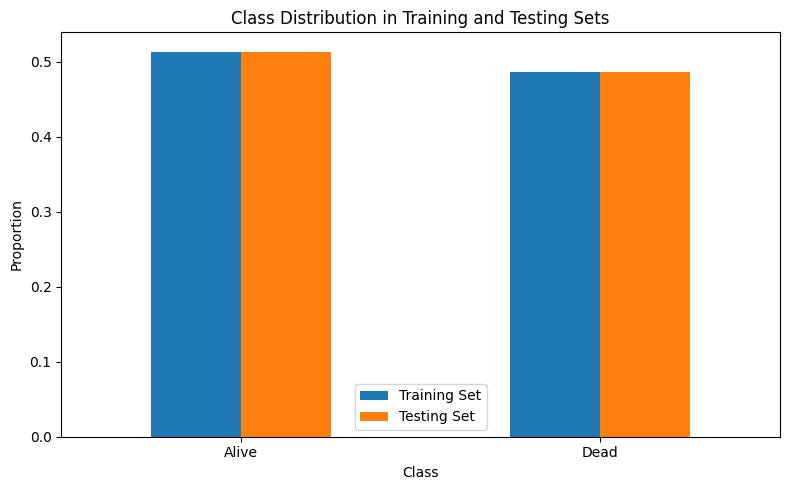

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# Data from your output
train_dist = {'Alive': 0.513478, 'Dead': 0.486522}
test_dist = {'Alive': 0.513471, 'Dead': 0.486529}

# Create a DataFrame for plotting
dist_df = pd.DataFrame({'Training Set': train_dist, 'Testing Set': test_dist})

# Plot
dist_df.plot(kind='bar', figsize=(8, 5), color=['#1f77b4', '#ff7f0e'])
plt.title('Class Distribution in Training and Testing Sets')
plt.ylabel('Proportion')
plt.xlabel('Class')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()

# Save the plot
plt.savefig('class_distribution.png', dpi=300)
plt.show()

In [ ]:
statistical analysis and test (

Descriptive Statistics for Categorical Features:

Age recode with <1 year olds:
Age recode with <1 year olds
60-64 years    24835
65-69 years    23206
55-59 years    22332
70-74 years    19084
50-54 years    15968
75-79 years    14229
80-84 years    10394
85+ years       9630
45-49 years     9054
40-44 years     4436
Other           3592
35-39 years     2392
Name: count, dtype: int64

Sex:
Sex
Male      113259
Female     45893
Name: count, dtype: int64

Site recode ICD-O-3 2023 Revision Expanded:
Site recode ICD-O-3 2023 Revision Expanded
Oropharynx                            47652
Larynx                                30855
Tongue Anterior                       18128
Major Salivary Glands                 13526
Lip                                    6879
Gum                                    6798
Nasopharynx                            6600
Nasal Cavity And Paranasal Sinuses     6519
Hypopharynx                            6158
Floor Of Mouth                         5268
Buccal Mucosa  

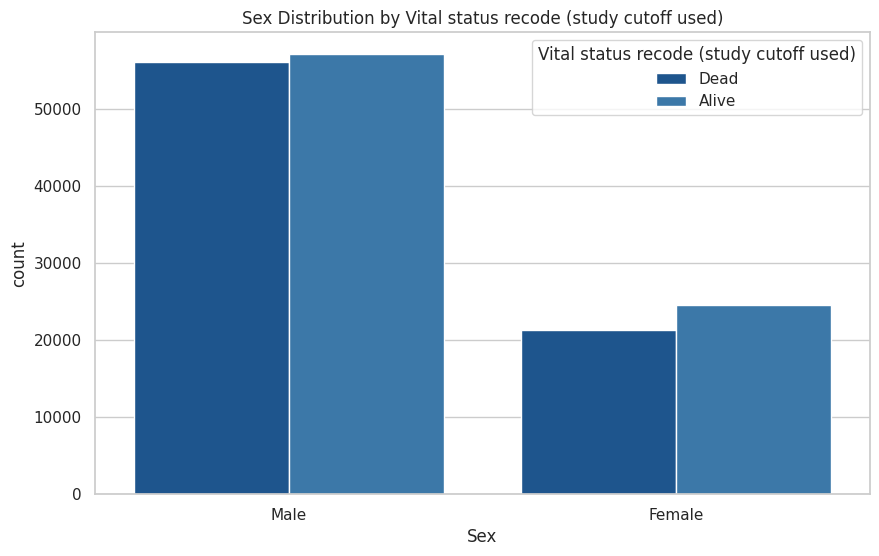

In [16]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Load the dataset (replace with your file path)
file_path = "15april_cleaned.csv"
df = pd.read_csv(file_path)

# Define the target column
target_col = 'Vital status recode (study cutoff used)'

# Step 1: Split the data into training and testing sets
X = df.drop(columns=[target_col])
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Step 2: Perform Statistical Analysis on Training Set
train_df = pd.concat([X_train, y_train], axis=1)

# 2.1 Descriptive Statistics for Categorical Features
print("Descriptive Statistics for Categorical Features:\n")
for col in train_df.select_dtypes(include=['object']).columns:
    print(f"{col}:\n{train_df[col].value_counts()}\n")

# 2.2 Chi-Square Test for Feature-Target Relationships (Categorical Features)
print("\nChi-Square Test for Feature-Target Relationships:\n")
for col in train_df.select_dtypes(include=['object']).columns:
    if col != target_col:
        contingency_table = pd.crosstab(train_df[col], train_df[target_col])
        chi2, p, _, _ = chi2_contingency(contingency_table)
        print(f"{col}: chi2 = {chi2:.2f}, p-value = {p:.4f}")

# 2.3 Correlation Analysis for Numerical Features
numerical_cols = train_df.select_dtypes(include=[np.number]).columns
if len(numerical_cols) > 0:
    corr_matrix = train_df[numerical_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
    plt.title("Correlation Matrix of Numerical Features")
    plt.savefig('correlation_matrix.png')
    print("\nCorrelation matrix saved as 'correlation_matrix.png'.")
else:
    print("\nNo numerical features for correlation analysis.")

# 2.4 Optional Visualization (replace 'Sex' with a relevant categorical feature)
if 'Sex' in train_df.columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(x='Sex', hue=target_col, data=train_df)
    plt.title(f"Sex Distribution by {target_col}")
    plt.savefig('sex_distribution.png')
    print("Feature-target visualization saved as 'sex_distribution.png'.")

/tmp/ipykernel_2703835/2345502008.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=features, x=chi2_stats, palette='mako')


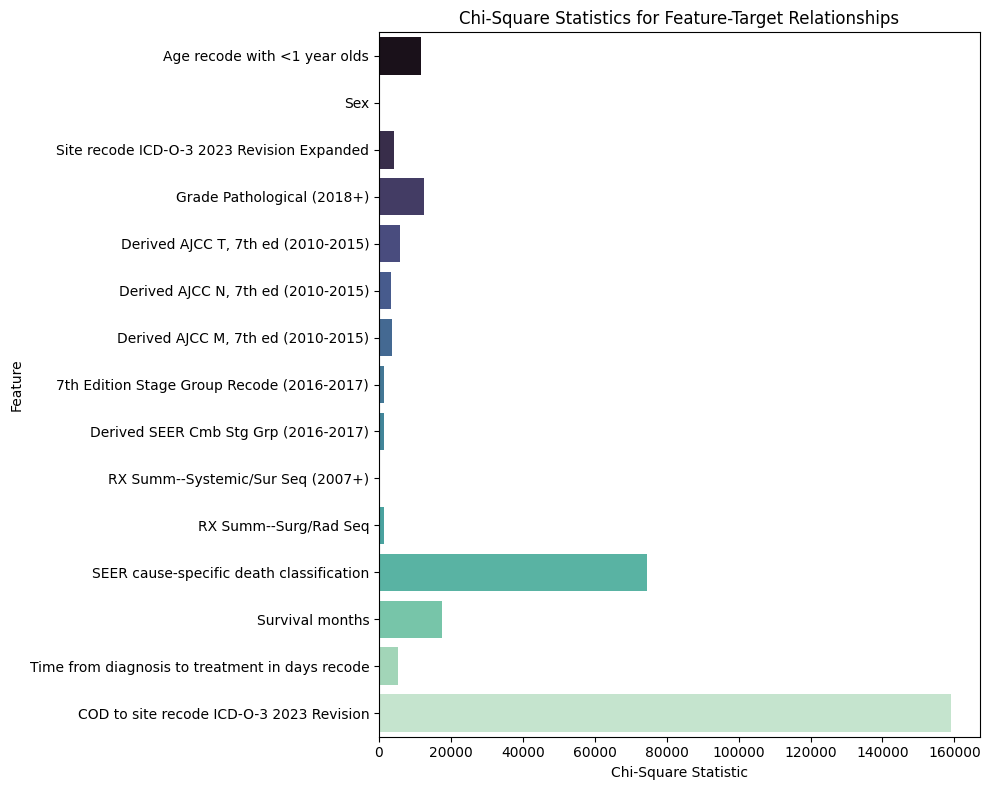

In [3]:
import matplotlib.pyplot as plt

features = [
    'Age recode with <1 year olds', 'Sex', 'Site recode ICD-O-3 2023 Revision Expanded',
    'Grade Pathological (2018+)', 'Derived AJCC T, 7th ed (2010-2015)',
    'Derived AJCC N, 7th ed (2010-2015)', 'Derived AJCC M, 7th ed (2010-2015)',
    '7th Edition Stage Group Recode (2016-2017)', 'Derived SEER Cmb Stg Grp (2016-2017)',
    'RX Summ--Systemic/Sur Seq (2007+)', 'RX Summ--Surg/Rad Seq',
    'SEER cause-specific death classification', 'Survival months',
    'Time from diagnosis to treatment in days recode', 'COD to site recode ICD-O-3 2023 Revision'
]
chi2_stats = [
    11679.40, 129.14, 4239.16, 12672.12, 5738.41, 3356.46, 3665.00, 1500.52, 1513.62,
    108.53, 1290.92, 74545.68, 17619.72, 5249.46, 159152.00
]

plt.figure(figsize=(10, 8))
sns.barplot(y=features, x=chi2_stats, palette='mako')
plt.xlabel('Chi-Square Statistic')
plt.ylabel('Feature')
plt.title('Chi-Square Statistics for Feature-Target Relationships')
plt.tight_layout()
plt.show()


data preprocessing - encoding the data

In [17]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

# Load the dataset (update file path as needed)
file_path = "15april_cleaned.csv"
df = pd.read_csv(file_path)

# Define target and features
target_col = 'Vital status recode (study cutoff used)'
X = df.drop(columns=[target_col])
y = df[target_col]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Identify categorical columns (all columns in this case)
categorical_cols = X_train.columns

# Apply one-hot encoding
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_encoded = encoder.fit_transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

# Get feature names
encoded_feature_names = encoder.get_feature_names_out(categorical_cols)

# Convert to DataFrames
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoded_feature_names, index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoded_feature_names, index=X_test.index)

# Final datasets (all columns are now encoded)
X_train = X_train_encoded_df
X_test = X_test_encoded_df

# Verify shapes
print(f"Encoded training set shape: {X_train.shape}")
print(f"Encoded testing set shape: {X_test.shape}")

Encoded training set shape: (159152, 144)
Encoded testing set shape: (39788, 144)


=== Dataset Overview ===
Shape: (198940, 19)

Columns and Data Types:
 Age recode with <1 year olds                       object
Sex                                                object
Site recode ICD-O-3 2023 Revision Expanded         object
Grade Pathological (2018+)                         object
Derived AJCC T, 7th ed (2010-2015)                 object
Derived AJCC N, 7th ed (2010-2015)                 object
Derived AJCC M, 7th ed (2010-2015)                 object
7th Edition Stage Group Recode (2016-2017)         object
Derived SEER Cmb Stg Grp (2016-2017)               object
RX Summ--Surg/Rad Seq                              object
SEER cause-specific death classification           object
Survival months                                    object
Time from diagnosis to treatment in days recode    object
COD to site recode ICD-O-3 2023 Revision           object
Vital status recode (study cutoff used)            object
Seq_None                                             bool
S

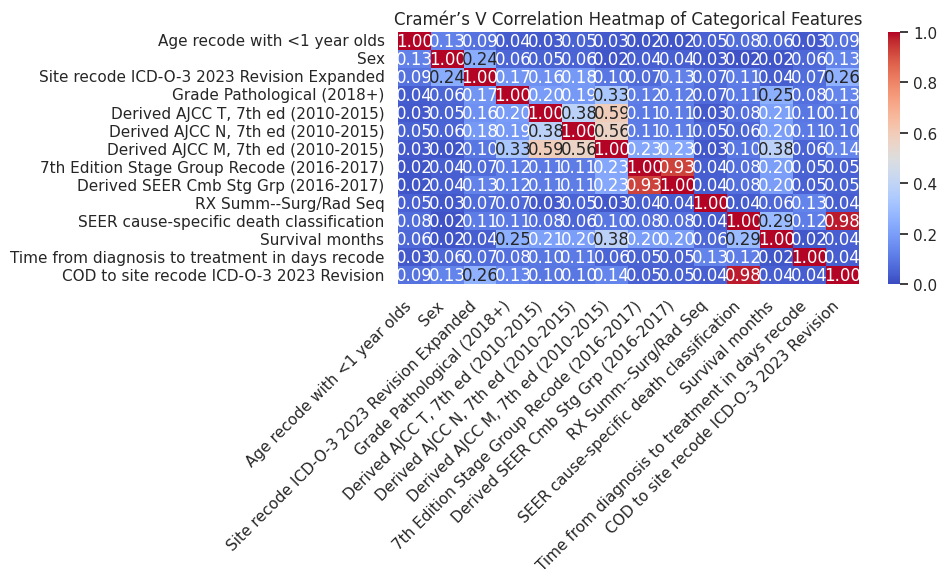


=== Feature Selection Insights (Cramér’s V) ===
Highly correlated categorical feature pairs (Cramér’s V > 0.8):
- 7th Edition Stage Group Recode (2016-2017) and Derived SEER Cmb Stg Grp (2016-2017): 0.93
  Suggestion: Consider removing one of these features to reduce redundancy.
- SEER cause-specific death classification and COD to site recode ICD-O-3 2023 Revision: 0.98
  Suggestion: Consider removing one of these features to reduce redundancy.

=== Point-Biserial Correlation with Binary Target ===
Point-biserial correlations with target (significant if p-value < 0.05):
- Age recode with <1 year olds: correlation = 0.26, p-value = 0.0000
- Sex: correlation = 0.03, p-value = 0.0000
  Suggestion: Sex has weak correlation and may be less useful.
- Site recode ICD-O-3 2023 Revision Expanded: correlation = -0.09, p-value = 0.0000
  Suggestion: Site recode ICD-O-3 2023 Revision Expanded has weak correlation and may be less useful.
- Grade Pathological (2018+): correlation = 0.23, p-value =

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import numpy as np
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder

# Set style for better visualizations
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Function to sanitize filenames
def sanitize_filename(name):
    return re.sub(r'[^\w\s-]', '_', name).strip('_').replace(' ', '_')

# Function to compute Cramér’s V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Create directory for saving plots
plots_dir = 'eda_plots'
os.makedirs(plots_dir, exist_ok=True)

# Load the dataset (update file path as needed)
file_path = "15april_cleaned.csv"
df = pd.read_csv(file_path)

# Define target column
target_col = 'Vital status recode (study cutoff used)'

# 1. Basic Dataset Overview
print("=== Dataset Overview ===")
print(f"Shape: {df.shape}")
print("\nColumns and Data Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nSample Data (first 5 rows):\n", df.head())

# 2. Identify Numerical and Categorical Columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
if target_col in categorical_cols:
    categorical_cols.remove(target_col)
if target_col in numerical_cols:
    numerical_cols.remove(target_col)

print(f"\nNumerical Columns: {numerical_cols}")
print(f"Categorical Columns: {categorical_cols}")
print(f"Target Column Type: {df[target_col].dtype}")

# 3. Check for Misclassified Numerical Columns
print("\nChecking for potential numerical columns stored as strings...")
for col in categorical_cols:
    try:
        df[col].astype(float)
        print(f"- {col}: Could be numerical (convertible to float). Consider converting.")
    except:
        pass

# 4. Correlation Heatmap for Categorical Features (Cramér’s V)
if categorical_cols:
    print("\n=== Categorical Feature Correlation (Cramér’s V) ===")
    # Compute Cramér’s V matrix
    n = len(categorical_cols)
    cramer_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                cramer_matrix[i, j] = 1.0
            else:
                cramer_matrix[i, j] = cramers_v(df[categorical_cols[i]], df[categorical_cols[j]])
    
    # Create heatmap
    plt.figure()
    sns.heatmap(cramer_matrix, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt='.2f',
                xticklabels=categorical_cols, yticklabels=categorical_cols)
    plt.title('Cramér’s V Correlation Heatmap of Categorical Features')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'categorical_correlation_heatmap.png'))
    plt.show()  # Display for manual screenshot
    plt.close()

    # Feature Selection Insights
    print("\n=== Feature Selection Insights (Cramér’s V) ===")
    print("Highly correlated categorical feature pairs (Cramér’s V > 0.8):")
    high_corr_pairs = []
    for i in range(n):
        for j in range(i + 1, n):
            if cramer_matrix[i, j] > 0.8:
                high_corr_pairs.append((categorical_cols[i], categorical_cols[j], cramer_matrix[i, j]))
    if high_corr_pairs:
        for feat1, feat2, corr in high_corr_pairs:
            print(f"- {feat1} and {feat2}: {corr:.2f}")
            print(f"  Suggestion: Consider removing one of these features to reduce redundancy.")
    else:
        print("No categorical feature pairs with Cramér’s V > 0.8 found.")
else:
    print("\nNo categorical columns found for correlation analysis.")

# 5. Target Correlation Analysis (if target is binary)
if df[target_col].dtype == 'object' or df[target_col].dtype.name == 'category':
    unique_values = df[target_col].nunique()
    if unique_values == 2:
        print("\n=== Point-Biserial Correlation with Binary Target ===")
        # Encode binary target (e.g., 'Alive' -> 1, 'Dead' -> 0)
        target_encoded = pd.Categorical(df[target_col]).codes
        # Encode categorical features for point-biserial correlation
        point_biserial_corrs = []
        for col in categorical_cols:
            # Label encode the categorical feature
            le = LabelEncoder()
            feature_encoded = le.fit_transform(df[col].astype(str))
            if df[col].notnull().sum() > 0:  # Ensure non-empty column
                corr, p_value = pointbiserialr(target_encoded, feature_encoded)
                point_biserial_corrs.append((col, corr, p_value))
        if point_biserial_corrs:
            print("Point-biserial correlations with target (significant if p-value < 0.05):")
            for col, corr, p_value in point_biserial_corrs:
                print(f"- {col}: correlation = {corr:.2f}, p-value = {p_value:.4f}")
                if abs(corr) > 0.3:
                    print(f"  Suggestion: {col} may be a strong predictor for the target.")
                elif abs(corr) < 0.1:
                    print(f"  Suggestion: {col} has weak correlation and may be less useful.")
        else:
            print("No categorical columns to compute point-biserial correlation.")
    else:
        print(f"\nTarget has {unique_values} categories. Point-biserial correlation not applicable.")
else:
    print("\nTarget type not suitable for point-biserial correlation analysis.")

print(f"\nCorrelation analysis completed. Heatmap saved in '{plots_dir}/categorical_correlation_heatmap.png'.")
print("Use displayed heatmap or saved PNG for visualization.")

In [6]:
# Install the UMAP package
!pip install umap-learn


Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for umap-learn from https://files.pythonhosted.org/packages/3c/8f/671c0e1f2572ba625cbcc1faeba9435e00330c3d6962858711445cf1e817/umap_learn-0.5.7-py3-none-any.whl.metadata
  Obtaining dependency information for numba>=0.51.2 from https://files.pythonhosted.org/packages/e2/7d/bfb2805bcfbd479f04f835241ecf28519f6e3609912e3a985aed45e21370/numba-0.61.2-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata
  Obtaining dependency information for pynndescent>=0.5 from https://files.pythonhosted.org/packages/d2/53/d23a97e0a2c690d40b165d1062e2c4ccc796be458a1ce59f6ba030434663/pynndescent-0.5.13-py3-none-any.whl.metadata
  Obtaining dependency information for tqdm from https://files.pythonhosted.org/packages/d0/30/dc54f88dd4a2b5dc8a0279bdd7270e735851848b762aeb1c1184ed1f6b14/tqdm-4.67.1-py3-none-any.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 5.3 M

/home/students/srtiwari/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-05-09 21:45:44.752056: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-09 21:45:44.786068: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9498] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-09 21:45:44.786089: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-09 21:45:4

Instructions for updating:
The TensorFlow Distributions library has moved to TensorFlow Probability (https://github.com/tensorflow/probability). You should update all references to use `tfp.distributions` instead of `tf.distributions`.
Instructions for updating:
The TensorFlow Distributions library has moved to TensorFlow Probability (https://github.com/tensorflow/probability). You should update all references to use `tfp.distributions` instead of `tf.distributions`.


2025-05-09 21:45:45.517981: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/home/students/srtiwari/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/students/srtiwari/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


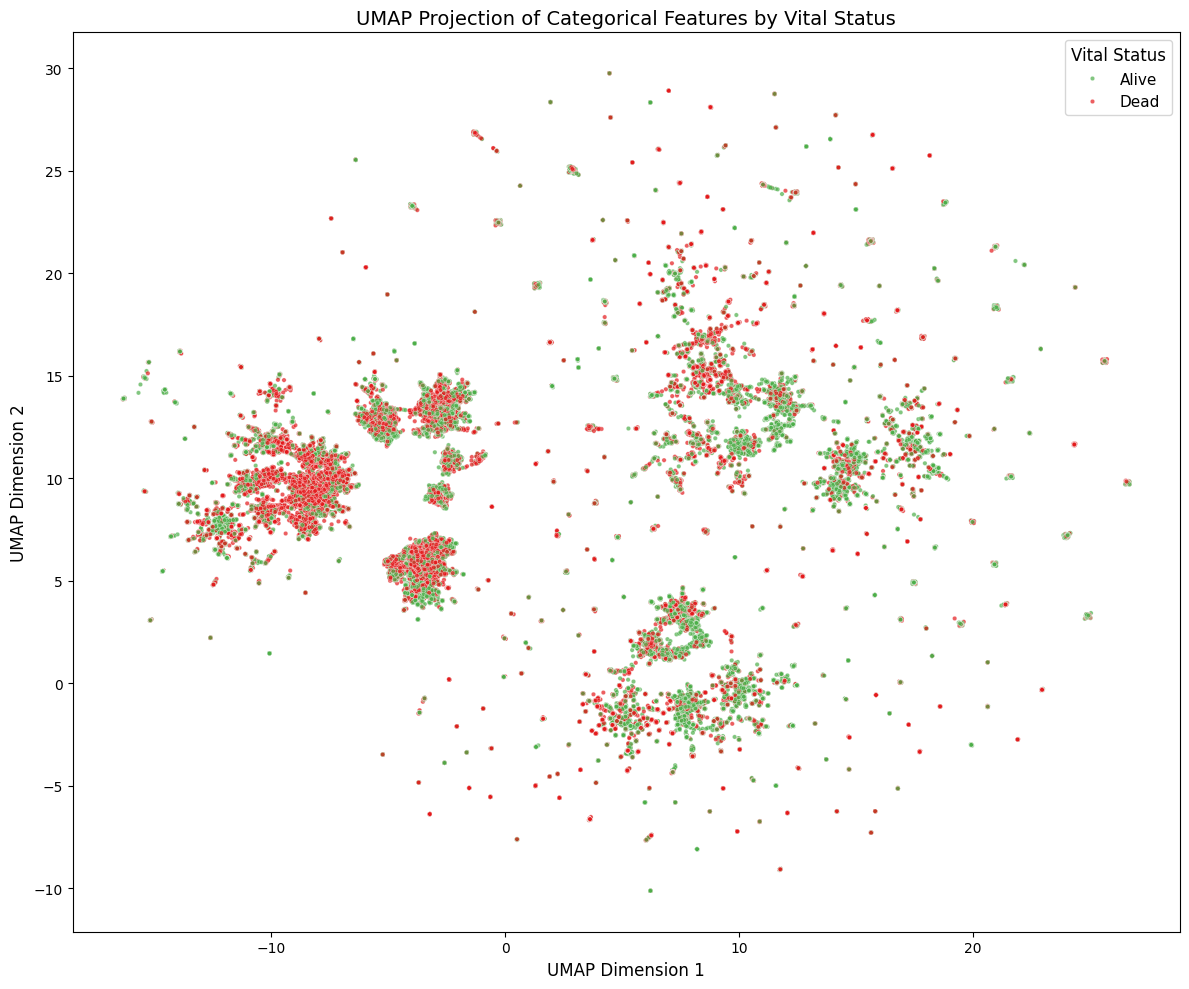

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OneHotEncoder
import umap
from sklearn.model_selection import train_test_split

# Load the dataset (replace with your file path)
file_path = "15april_cleaned.csv"
df = pd.read_csv(file_path)

# Define the target column
target_col = 'Vital status recode (study cutoff used)'

# Split the data into training and testing sets
X = df.drop(columns=[target_col])
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Recreate train_df by combining features and target
train_df = pd.concat([X_train, y_train], axis=1)

# Select categorical columns for analysis
categorical_cols = [
    'Age recode with <1 year olds', 
    'Sex', 
    'Site recode ICD-O-3 2023 Revision Expanded',
    'Grade Pathological (2018+)',
    'Derived AJCC T, 7th ed (2010-2015)',
    'Derived AJCC N, 7th ed (2010-2015)',
    'Derived AJCC M, 7th ed (2010-2015)',
    'RX Summ--Systemic/Sur Seq (2007+)',
    'RX Summ--Surg/Rad Seq'
]

# Handle missing values (if any)
for col in categorical_cols:
    if col in train_df.columns:
        train_df[col] = train_df[col].fillna('Missing')

# Select only columns that exist in the dataframe
valid_cols = [col for col in categorical_cols if col in train_df.columns]

# Encode categorical variables
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_encoded = encoder.fit_transform(train_df[valid_cols])

# Fit UMAP for dimensionality reduction
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(X_encoded)

# Define color palette: green for Alive, red for Dead
status_palette = {'Alive': '#4daf4a', 'Dead': '#e41a1c'}

# Plot UMAP and save as PNG
plt.figure(figsize=(12, 10))
scatter = sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    hue=train_df[target_col],
    palette=status_palette,
    alpha=0.7,
    s=10,
    hue_order=['Alive', 'Dead']  # Ensures consistent color mapping
)

plt.title('UMAP Projection of Categorical Features by Vital Status', fontsize=14)
plt.xlabel('UMAP Dimension 1', fontsize=12)
plt.ylabel('UMAP Dimension 2', fontsize=12)

# Legend formatting
plt.legend(
    title='Vital Status',
    title_fontsize=12,
    fontsize=11,
    loc='upper right',
    frameon=True,
    facecolor='white'
)

# Save the plot before showing it
plt.savefig('umap_visualization.png', dpi=300, bbox_inches='tight', facecolor='white')

plt.tight_layout()
plt.show()


In [19]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Load the cleaned dataset
file_path = "15april_cleaned.csv"  # Update this to your cleaned dataset's path
df = pd.read_csv(file_path)

# Define target and features, excluding problematic features
target_col = 'Vital status recode (study cutoff used)'
exclude_cols = [
    target_col,
    'COD to site recode ICD-O-3 2023 Revision',  # Direct proxy for target
    'SEER cause-specific death classification'   # Direct proxy for target
]
X = df.drop(columns=exclude_cols)
y = df[target_col]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Apply one-hot encoding to categorical features
categorical_cols = X_train.select_dtypes(include=['object']).columns
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_encoded = encoder.fit_transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

# Get feature names and convert to DataFrames
encoded_feature_names = encoder.get_feature_names_out(categorical_cols)
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoded_feature_names, index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoded_feature_names, index=X_test.index)

# Drop original categorical columns and concatenate encoded ones
X_train = X_train.drop(columns=categorical_cols).join(X_train_encoded_df)
X_test = X_test.drop(columns=categorical_cols).join(X_test_encoded_df)

# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)

# Perform 5-fold cross-validation on the training set
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
print(f"Cross-Validation ROC-AUC Scores: {cv_scores}")
print(f"Mean CV ROC-AUC: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

# Train the model on the full training set
rf_model.fit(X_train, y_train)

# Evaluate on the training set
y_train_pred = rf_model.predict(X_train)
y_train_proba = rf_model.predict_proba(X_train)[:, 1]
train_roc_auc = roc_auc_score(y_train, y_train_proba)
print("\nTraining Set Performance:")
print("Classification Report:\n", classification_report(y_train, y_train_pred))
print(f"ROC-AUC: {train_roc_auc:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))

# Evaluate on the test set
y_test_pred = rf_model.predict(X_test)
y_test_proba = rf_model.predict_proba(X_test)[:, 1]
test_roc_auc = roc_auc_score(y_test, y_test_proba)
print("\nTest Set Performance:")
print("Classification Report:\n", classification_report(y_test, y_test_pred))
print(f"ROC-AUC: {test_roc_auc:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print("\nTop 10 Feature Importances:\n", feature_importance.head(10))

Cross-Validation ROC-AUC Scores: [0.83268988 0.83324809 0.83114561 0.83354311 0.82868996]
Mean CV ROC-AUC: 0.8319 ± 0.0018

Training Set Performance:
Classification Report:
               precision    recall  f1-score   support

       Alive       0.87      0.92      0.89     81721
        Dead       0.91      0.86      0.88     77431

    accuracy                           0.89    159152
   macro avg       0.89      0.89      0.89    159152
weighted avg       0.89      0.89      0.89    159152

ROC-AUC: 0.9633
Confusion Matrix:
 [[74878  6843]
 [10958 66473]]

Test Set Performance:
Classification Report:
               precision    recall  f1-score   support

       Alive       0.75      0.81      0.78     20430
        Dead       0.78      0.71      0.74     19358

    accuracy                           0.76     39788
   macro avg       0.76      0.76      0.76     39788
weighted avg       0.76      0.76      0.76     39788

ROC-AUC: 0.8331
Confusion Matrix:
 [[16519  3911]
 [ 5627 1

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Load the cleaned dataset
file_path = "15april_cleaned.csv"  # Update this to your cleaned dataset's path
df = pd.read_csv(file_path)

# Define target and features, excluding problematic features
target_col = 'Vital status recode (study cutoff used)'
exclude_cols = [
    target_col,
    'COD to site recode ICD-O-3 2023 Revision',
    'SEER cause-specific death classification'
]
X = df.drop(columns=exclude_cols)
y = df[target_col]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Apply one-hot encoding to categorical features
categorical_cols = X_train.select_dtypes(include=['object']).columns
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_encoded = encoder.fit_transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

# Get feature names and convert to DataFrames
encoded_feature_names = encoder.get_feature_names_out(categorical_cols)
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoded_feature_names, index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoded_feature_names, index=X_test.index)

# Drop original categorical columns and concatenate encoded ones
X_train = X_train.drop(columns=categorical_cols).join(X_train_encoded_df)
X_test = X_test.drop(columns=categorical_cols).join(X_test_encoded_df)

# Initialize a lightweight Random Forest for RFECV
rf_for_rfecv = RandomForestClassifier(
    n_estimators=50,  # Fewer trees to speed up
    random_state=42,
    n_jobs=-1
)

# Perform RFECV
rfecv = RFECV(
    estimator=rf_for_rfecv,
    step=10,  # Remove 10 features at a time to speed up
    cv=3,     # Use 3-fold CV to reduce computation
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Fit RFECV
rfecv.fit(X_train, y_train)

# Get selected features
selected_features = X_train.columns[rfecv.support_]
print(f"\nNumber of selected features: {len(selected_features)}")
print("Selected features:\n", selected_features)

# Subset training and test sets to selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Train a Random Forest on selected features
rf_model = RandomForestClassifier(
    n_estimators=100,  # Moderate number of trees
    random_state=42,
    n_jobs=-1
)

# Perform 3-fold cross-validation on the selected features
cv_scores = cross_val_score(rf_model, X_train_selected, y_train, cv=3, scoring='roc_auc', n_jobs=-1)
print(f"\nCross-Validation ROC-AUC Scores (Selected Features): {cv_scores}")
print(f"Mean CV ROC-AUC: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

# Train the model on the full training set with selected features
rf_model.fit(X_train_selected, y_train)

# Evaluate on the training set
y_train_pred = rf_model.predict(X_train_selected)
y_train_proba = rf_model.predict_proba(X_train_selected)[:, 1]
train_roc_auc = roc_auc_score(y_train, y_train_proba)
print("\nTraining Set Performance (Selected Features):")
print("Classification Report:\n", classification_report(y_train, y_train_pred))
print(f"ROC-AUC: {train_roc_auc:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))

# Evaluate on the test set
y_test_pred = rf_model.predict(X_test_selected)
y_test_proba = rf_model.predict_proba(X_test_selected)[:, 1]
test_roc_auc = roc_auc_score(y_test, y_test_proba)
print("\nTest Set Performance (Selected Features):")
print("Classification Report:\n", classification_report(y_test, y_test_pred))
print(f"ROC-AUC: {test_roc_auc:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

# Feature Importance for selected features
feature_importance = pd.DataFrame({
    'Feature': X_train_selected.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print("\nTop 10 Feature Importances (Selected Features):\n", feature_importance.head(10))

Fitting estimator with 125 features.
Fitting estimator with 115 features.
Fitting estimator with 105 features.
Fitting estimator with 95 features.
Fitting estimator with 85 features.
Fitting estimator with 75 features.
Fitting estimator with 65 features.
Fitting estimator with 55 features.
Fitting estimator with 45 features.
Fitting estimator with 35 features.

Number of selected features: 25
Selected features:
 Index(['Age recode with <1 year olds_60-64 years',
       'Age recode with <1 year olds_65-69 years',
       'Age recode with <1 year olds_70-74 years',
       'Age recode with <1 year olds_75-79 years',
       'Age recode with <1 year olds_80-84 years',
       'Age recode with <1 year olds_85+ years',
       'Site recode ICD-O-3 2023 Revision Expanded_Hypopharynx',
       'Site recode ICD-O-3 2023 Revision Expanded_Larynx',
       'Site recode ICD-O-3 2023 Revision Expanded_Major Salivary Glands',
       'Site recode ICD-O-3 2023 Revision Expanded_Oropharynx',
       'Site rec

Recommended Approach: Class Weighting and Feature Adjustment

In [6]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Load the cleaned dataset
file_path = "15april_cleaned.csv"  # Update this to your cleaned dataset's path
df = pd.read_csv(file_path)

# Define target and features, excluding problematic features and 'Survival months'
target_col = 'Vital status recode (study cutoff used)'
exclude_cols = [
    target_col,
    'COD to site recode ICD-O-3 2023 Revision',
    'SEER cause-specific death classification',
    'Survival months'  # Exclude to test for potential leakage
]
X = df.drop(columns=exclude_cols)
y = df[target_col]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Apply one-hot encoding to categorical features
categorical_cols = X_train.select_dtypes(include=['object']).columns
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_encoded = encoder.fit_transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

# Get feature names and convert to DataFrames
encoded_feature_names = encoder.get_feature_names_out(categorical_cols)
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoded_feature_names, index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoded_feature_names, index=X_test.index)

# Drop original categorical columns and concatenate encoded ones
X_train = X_train.drop(columns=categorical_cols).join(X_train_encoded_df)
X_test = X_test.drop(columns=categorical_cols).join(X_test_encoded_df)

# Filter to use only the previously selected features (minus 'Survival months')
selected_features = [
    'Age recode with <1 year olds_60-64 years',
    'Age recode with <1 year olds_65-69 years',
    'Age recode with <1 year olds_70-74 years',
    'Age recode with <1 year olds_75-79 years',
    'Age recode with <1 year olds_80-84 years',
    'Age recode with <1 year olds_85+ years',
    'Site recode ICD-O-3 2023 Revision Expanded_Hypopharynx',
    'Site recode ICD-O-3 2023 Revision Expanded_Larynx',
    'Site recode ICD-O-3 2023 Revision Expanded_Major Salivary Glands',
    'Site recode ICD-O-3 2023 Revision Expanded_Oropharynx',
    'Site recode ICD-O-3 2023 Revision Expanded_Tongue Anterior',
    'Grade Pathological (2018+)_2',
    'Grade Pathological (2018+)_9',
    'Grade Pathological (2018+)_Blank(s)',
    'Derived AJCC T, 7th ed (2010-2015)_T1',
    'Derived AJCC T, 7th ed (2010-2015)_T2',
    'Derived AJCC N, 7th ed (2010-2015)_N0',
    'Derived AJCC M, 7th ed (2010-2015)_Blank(s)',
    'Derived AJCC M, 7th ed (2010-2015)_M0',
    '7th Edition Stage Group Recode (2016-2017)_Blank(s)',
    'Derived SEER Cmb Stg Grp (2016-2017)_Blank(s)',
    'Time from diagnosis to treatment in days recode_000',
    'Time from diagnosis to treatment in days recode_Other',
    'Time from diagnosis to treatment in days recode_Unable to calculate'
]

# Subset training and test sets to selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Initialize Random Forest with class weights
rf_model = RandomForestClassifier(
    n_estimators=100,  # Moderate number of trees for efficiency
    class_weight={'Alive': 1, 'Dead': 1.5},  # Increase weight for 'Dead' to improve recall
    random_state=42,
    n_jobs=-1
)

# Perform 3-fold cross-validation on the selected features
cv_scores = cross_val_score(rf_model, X_train_selected, y_train, cv=3, scoring='roc_auc', n_jobs=-1)
print(f"\nCross-Validation ROC-AUC Scores (Selected Features, Weighted): {cv_scores}")
print(f"Mean CV ROC-AUC: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

# Train the model on the full training set
rf_model.fit(X_train_selected, y_train)

# Evaluate on the training set
y_train_pred = rf_model.predict(X_train_selected)
y_train_proba = rf_model.predict_proba(X_train_selected)[:, 1]
train_roc_auc = roc_auc_score(y_train, y_train_proba)
print("\nTraining Set Performance (Selected Features, Weighted):")
print("Classification Report:\n", classification_report(y_train, y_train_pred))
print(f"ROC-AUC: {train_roc_auc:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))

# Evaluate on the test set
y_test_pred = rf_model.predict(X_test_selected)
y_test_proba = rf_model.predict_proba(X_test_selected)[:, 1]
test_roc_auc = roc_auc_score(y_test, y_test_proba)
print("\nTest Set Performance (Selected Features, Weighted):")
print("Classification Report:\n", classification_report(y_test, y_test_pred))
print(f"ROC-AUC: {test_roc_auc:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_train_selected.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print("\nTop 10 Feature Importances (Selected Features, Weighted):\n", feature_importance.head(10))


Cross-Validation ROC-AUC Scores (Selected Features, Weighted): [0.77761468 0.77705132 0.77471749]
Mean CV ROC-AUC: 0.7765 ± 0.0013

Training Set Performance (Selected Features, Weighted):
Classification Report:
               precision    recall  f1-score   support

       Alive       0.76      0.62      0.68     81721
        Dead       0.66      0.79      0.72     77431

    accuracy                           0.70    159152
   macro avg       0.71      0.71      0.70    159152
weighted avg       0.71      0.70      0.70    159152

ROC-AUC: 0.7891
Confusion Matrix:
 [[50578 31143]
 [16166 61265]]

Test Set Performance (Selected Features, Weighted):
Classification Report:
               precision    recall  f1-score   support

       Alive       0.75      0.62      0.68     20430
        Dead       0.66      0.78      0.72     19358

    accuracy                           0.70     39788
   macro avg       0.71      0.70      0.70     39788
weighted avg       0.71      0.70      0.70  


Cross-Validation ROC-AUC Scores (Selected Features, Weighted): [0.77761468 0.77705132 0.77471749]
Mean CV ROC-AUC: 0.7765 ± 0.0013

Training Set Performance (Selected Features, Weighted):
Classification Report:
               precision    recall  f1-score   support

       Alive       0.76      0.62      0.68     81721
        Dead       0.66      0.79      0.72     77431

    accuracy                           0.70    159152
   macro avg       0.71      0.71      0.70    159152
weighted avg       0.71      0.70      0.70    159152

ROC-AUC: 0.7891
Confusion Matrix:
 [[50578 31143]
 [16166 61265]]

Test Set Performance (Selected Features, Weighted):
Classification Report:
               precision    recall  f1-score   support

       Alive       0.75      0.62      0.68     20430
        Dead       0.66      0.78      0.72     19358

    accuracy                           0.70     39788
   macro avg       0.71      0.70      0.70     39788
weighted avg       0.71      0.70      0.70  

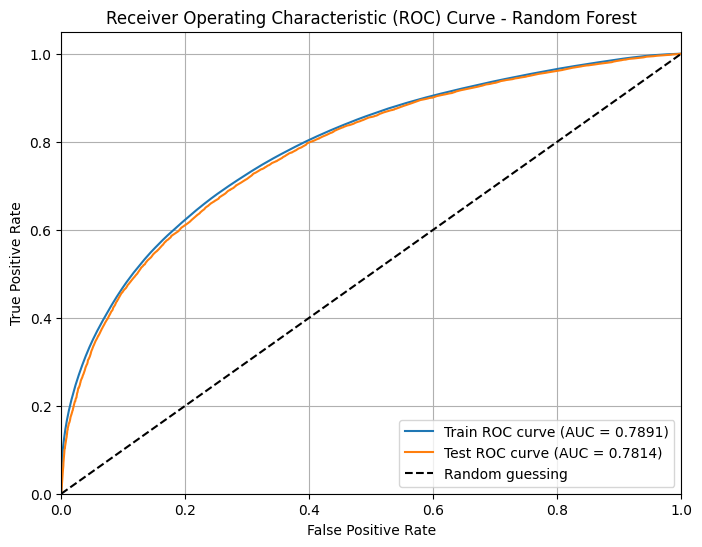

In [22]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

# Load the cleaned dataset
file_path = "15april_cleaned.csv"  # Update this to your cleaned dataset's path
df = pd.read_csv(file_path)

# Define target and features, excluding problematic features and 'Survival months'
target_col = 'Vital status recode (study cutoff used)'
exclude_cols = [
    target_col,
    'COD to site recode ICD-O-3 2023 Revision',
    'SEER cause-specific death classification',
    'Survival months'  # Exclude to test for potential leakage
]
X = df.drop(columns=exclude_cols)
y = df[target_col]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Apply one-hot encoding to categorical features
categorical_cols = X_train.select_dtypes(include=['object']).columns
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_encoded = encoder.fit_transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

# Get feature names and convert to DataFrames
encoded_feature_names = encoder.get_feature_names_out(categorical_cols)
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoded_feature_names, index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoded_feature_names, index=X_test.index)

# Drop original categorical columns and concatenate encoded ones
X_train = X_train.drop(columns=categorical_cols).join(X_train_encoded_df)
X_test = X_test.drop(columns=categorical_cols).join(X_test_encoded_df)

# Filter to use only the previously selected features (minus 'Survival months')
selected_features = [
    'Age recode with <1 year olds_60-64 years',
    'Age recode with <1 year olds_65-69 years',
    'Age recode with <1 year olds_70-74 years',
    'Age recode with <1 year olds_75-79 years',
    'Age recode with <1 year olds_80-84 years',
    'Age recode with <1 year olds_85+ years',
    'Site recode ICD-O-3 2023 Revision Expanded_Hypopharynx',
    'Site recode ICD-O-3 2023 Revision Expanded_Larynx',
    'Site recode ICD-O-3 2023 Revision Expanded_Major Salivary Glands',
    'Site recode ICD-O-3 2023 Revision Expanded_Oropharynx',
    'Site recode ICD-O-3 2023 Revision Expanded_Tongue Anterior',
    'Grade Pathological (2018+)_2',
    'Grade Pathological (2018+)_9',
    'Grade Pathological (2018+)_Blank(s)',
    'Derived AJCC T, 7th ed (2010-2015)_T1',
    'Derived AJCC T, 7th ed (2010-2015)_T2',
    'Derived AJCC N, 7th ed (2010-2015)_N0',
    'Derived AJCC M, 7th ed (2010-2015)_Blank(s)',
    'Derived AJCC M, 7th ed (2010-2015)_M0',
    '7th Edition Stage Group Recode (2016-2017)_Blank(s)',
    'Derived SEER Cmb Stg Grp (2016-2017)_Blank(s)',
    'Time from diagnosis to treatment in days recode_000',
    'Time from diagnosis to treatment in days recode_Other',
    'Time from diagnosis to treatment in days recode_Unable to calculate'
]

# Subset training and test sets to selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Initialize Random Forest with class weights
rf_model = RandomForestClassifier(
    n_estimators=100,  # Moderate number of trees for efficiency
    class_weight={'Alive': 1, 'Dead': 1.5},  # Increase weight for 'Dead' to improve recall
    random_state=42,
    n_jobs=-1
)

# Perform 3-fold cross-validation on the selected features
cv_scores = cross_val_score(rf_model, X_train_selected, y_train, cv=3, scoring='roc_auc', n_jobs=-1)
print(f"\nCross-Validation ROC-AUC Scores (Selected Features, Weighted): {cv_scores}")
print(f"Mean CV ROC-AUC: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

# Train the model on the full training set
rf_model.fit(X_train_selected, y_train)

# Evaluate on the training set
y_train_pred = rf_model.predict(X_train_selected)
y_train_proba = rf_model.predict_proba(X_train_selected)[:, 1]
train_roc_auc = roc_auc_score(y_train, y_train_proba)
print("\nTraining Set Performance (Selected Features, Weighted):")
print("Classification Report:\n", classification_report(y_train, y_train_pred))
print(f"ROC-AUC: {train_roc_auc:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))

# Evaluate on the test set
y_test_pred = rf_model.predict(X_test_selected)
y_test_proba = rf_model.predict_proba(X_test_selected)[:, 1]
test_roc_auc = roc_auc_score(y_test, y_test_proba)
print("\nTest Set Performance (Selected Features, Weighted):")
print("Classification Report:\n", classification_report(y_test, y_test_pred))
print(f"ROC-AUC: {test_roc_auc:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_train_selected.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print("\nTop 10 Feature Importances (Selected Features, Weighted):\n", feature_importance.head(10))

# Plot ROC curve for Random Forest
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba, pos_label='Dead')
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba, pos_label='Dead')
auc_train = auc(fpr_train, tpr_train)
auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f'Train ROC curve (AUC = {auc_train:.4f})')
plt.plot(fpr_test, tpr_test, label=f'Test ROC curve (AUC = {auc_test:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [21]:
# Check the number of feature vectors (features)
num_features = X_train_selected.shape[1]
print(f"Number of feature vectors (features) used in the model: {num_features}")
print("Feature names:", list(X_train_selected.columns))
#umap #tsne #pca

Number of feature vectors (features) used in the model: 24
Feature names: ['Age recode with less_than1 year olds_60-64 years', 'Age recode with less_than1 year olds_65-69 years', 'Age recode with less_than1 year olds_70-74 years', 'Age recode with less_than1 year olds_75-79 years', 'Age recode with less_than1 year olds_80-84 years', 'Age recode with less_than1 year olds_85+ years', 'Site recode ICD-O-3 2023 Revision Expanded_Hypopharynx', 'Site recode ICD-O-3 2023 Revision Expanded_Larynx', 'Site recode ICD-O-3 2023 Revision Expanded_Major Salivary Glands', 'Site recode ICD-O-3 2023 Revision Expanded_Oropharynx', 'Site recode ICD-O-3 2023 Revision Expanded_Tongue Anterior', 'Grade Pathological (2018+)_2', 'Grade Pathological (2018+)_9', 'Grade Pathological (2018+)_Blank(s)', 'Derived AJCC T, 7th ed (2010-2015)_T1', 'Derived AJCC T, 7th ed (2010-2015)_T2', 'Derived AJCC N, 7th ed (2010-2015)_N0', 'Derived AJCC M, 7th ed (2010-2015)_Blank(s)', 'Derived AJCC M, 7th ed (2010-2015)_M0', '7t

xgboost train

In [5]:
pip install --upgrade xgboost


Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for xgboost from https://files.pythonhosted.org/packages/63/f1/653afe1a1b7e1d03f26fd4bd30f3eebcfac2d8982e1a85b6be3355dcae25/xgboost-3.0.0-py3-none-manylinux_2_28_x86_64.whl.metadata
  Obtaining dependency information for nvidia-nccl-cu12 from https://files.pythonhosted.org/packages/9f/30/aa24e8e02cd860d80a31ee32cc3a0db9ffb93efb2556705db3ce6c924926/nvidia_nccl_cu12-2.26.2.post1-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 10.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.7/291.7 MB 9.5 MB/s eta 0:00:00:00:0100:01

[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import xgboost
import sklearn

# Check package versions
print(f"XGBoost version: {xgboost.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")

# Load and prepare data
file_path = "15april_cleaned.csv"
df = pd.read_csv(file_path)
target_col = 'Vital status recode (study cutoff used)'
exclude_cols = [target_col, 'COD to site recode ICD-O-3 2023 Revision',
                'SEER cause-specific death classification', 'Survival months']
X = df.drop(columns=exclude_cols)

# Rename columns to replace '<' with 'less_than' to avoid XGBoost error
X = X.rename(columns=lambda col: col.replace('<', 'less_than'))
y = LabelEncoder().fit_transform(df[target_col])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# One-hot encoding
cat_cols = X_train.select_dtypes(include=['object']).columns
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_encoded = pd.DataFrame(encoder.fit_transform(X_train[cat_cols]),
                               columns=encoder.get_feature_names_out(cat_cols),
                               index=X_train.index)
X_test_encoded = pd.DataFrame(encoder.transform(X_test[cat_cols]),
                              columns=encoder.get_feature_names_out(cat_cols),
                              index=X_test.index)
X_train = X_train.drop(columns=cat_cols).join(X_train_encoded)
X_test = X_test.drop(columns=cat_cols).join(X_test_encoded)

# Selected features with '<' replaced by 'less_than'
selected_features = [
    'Age recode with less_than1 year olds_60-64 years',
    'Age recode with less_than1 year olds_65-69 years',
    'Age recode with less_than1 year olds_70-74 years',
    'Age recode with less_than1 year olds_75-79 years',
    'Age recode with less_than1 year olds_80-84 years',
    'Age recode with less_than1 year olds_85+ years',
    'Site recode ICD-O-3 2023 Revision Expanded_Hypopharynx',
    'Site recode ICD-O-3 2023 Revision Expanded_Larynx',
    'Site recode ICD-O-3 2023 Revision Expanded_Major Salivary Glands',
    'Site recode ICD-O-3 2023 Revision Expanded_Oropharynx',
    'Site recode ICD-O-3 2023 Revision Expanded_Tongue Anterior',
    'Grade Pathological (2018+)_2',
    'Grade Pathological (2018+)_9',
    'Grade Pathological (2018+)_Blank(s)',
    'Derived AJCC T, 7th ed (2010-2015)_T1',
    'Derived AJCC T, 7th ed (2010-2015)_T2',
    'Derived AJCC N, 7th ed (2010-2015)_N0',
    'Derived AJCC M, 7th ed (2010-2015)_Blank(s)',
    'Derived AJCC M, 7th ed (2010-2015)_M0',
    '7th Edition Stage Group Recode (2016-2017)_Blank(s)',
    'Derived SEER Cmb Stg Grp (2016-2017)_Blank(s)',
    'Time from diagnosis to treatment in days recode_000',
    'Time from diagnosis to treatment in days recode_Other',
    'Time from diagnosis to treatment in days recode_Unable to calculate'
]

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Initialize XGBoost without use_label_encoder to avoid warning
xgb_model = XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=sum(y_train == 0)/sum(y_train == 1),
    eval_metric='auc',
    early_stopping_rounds=10,
    random_state=42,
    n_jobs=-1
)

# Manual 3-fold cross-validation
print("\n--- Cross-Validation Results ---")
cv = StratifiedKFold(n_splits=3)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_selected, y_train)):
    X_fold_train, y_fold_train = X_train_selected.iloc[train_idx], y_train[train_idx]
    X_fold_val, y_fold_val = X_train_selected.iloc[val_idx], y_train[val_idx]
    
    xgb_model.fit(
        X_fold_train, y_fold_train,
        eval_set=[(X_fold_val, y_fold_val)],
        verbose=False
    )
    
    y_val_proba = xgb_model.predict_proba(X_fold_val)[:, 1]
    fold_auc = roc_auc_score(y_fold_val, y_val_proba)
    cv_scores.append(fold_auc)
    print(f"Fold {fold+1}: {fold_auc:.4f}")

print(f"\nMean ROC-AUC: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

# Final training
print("\n--- Final Training ---")
xgb_model.fit(
    X_train_selected, y_train,
    eval_set=[(X_test_selected, y_test)],
    verbose=False
)

# Training set evaluation
y_train_pred = xgb_model.predict(X_train_selected)
y_train_proba = xgb_model.predict_proba(X_train_selected)[:, 1]
print("\n--- Training Performance ---")
print("Classification Report:")
print(classification_report(y_train, y_train_pred, target_names=['Alive', 'Dead']))
print(f"ROC-AUC: {roc_auc_score(y_train, y_train_proba):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_train, y_train_pred))

# Test set evaluation
y_test_pred = xgb_model.predict(X_test_selected)
y_test_proba = xgb_model.predict_proba(X_test_selected)[:, 1]
print("\n--- Test Performance ---")
print("Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Alive', 'Dead']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_proba):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train_selected.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)
print("\n--- Top 10 Features ---")
print(feature_importance.head(10).to_string(index=False))

XGBoost version: 3.0.0
scikit-learn version: 1.6.1

--- Cross-Validation Results ---
Fold 1: 0.7822
Fold 2: 0.7834
Fold 3: 0.7793

Mean ROC-AUC: 0.7816 ± 0.0017

--- Final Training ---

--- Training Performance ---
Classification Report:
              precision    recall  f1-score   support

       Alive       0.72      0.72      0.72     81721
        Dead       0.71      0.70      0.70     77431

    accuracy                           0.71    159152
   macro avg       0.71      0.71      0.71    159152
weighted avg       0.71      0.71      0.71    159152

ROC-AUC: 0.7854
Confusion Matrix:
[[59026 22695]
 [22937 54494]]

--- Test Performance ---
Classification Report:
              precision    recall  f1-score   support

       Alive       0.72      0.72      0.72     20430
        Dead       0.70      0.70      0.70     19358

    accuracy                           0.71     39788
   macro avg       0.71      0.71      0.71     39788
weighted avg       0.71      0.71      0.71     3

XGBoost version: 3.0.0
scikit-learn version: 1.6.1

--- Cross-Validation Results ---
Fold 1: 0.7822
Fold 2: 0.7834
Fold 3: 0.7793

Mean ROC-AUC: 0.7816 ± 0.0017

--- Final Training ---

--- Training Performance ---
Classification Report:
              precision    recall  f1-score   support

       Alive       0.72      0.72      0.72     81721
        Dead       0.71      0.70      0.70     77431

    accuracy                           0.71    159152
   macro avg       0.71      0.71      0.71    159152
weighted avg       0.71      0.71      0.71    159152

ROC-AUC: 0.7854
Confusion Matrix:
[[59026 22695]
 [22937 54494]]

--- Test Performance ---
Classification Report:
              precision    recall  f1-score   support

       Alive       0.72      0.72      0.72     20430
        Dead       0.70      0.70      0.70     19358

    accuracy                           0.71     39788
   macro avg       0.71      0.71      0.71     39788
weighted avg       0.71      0.71      0.71     3

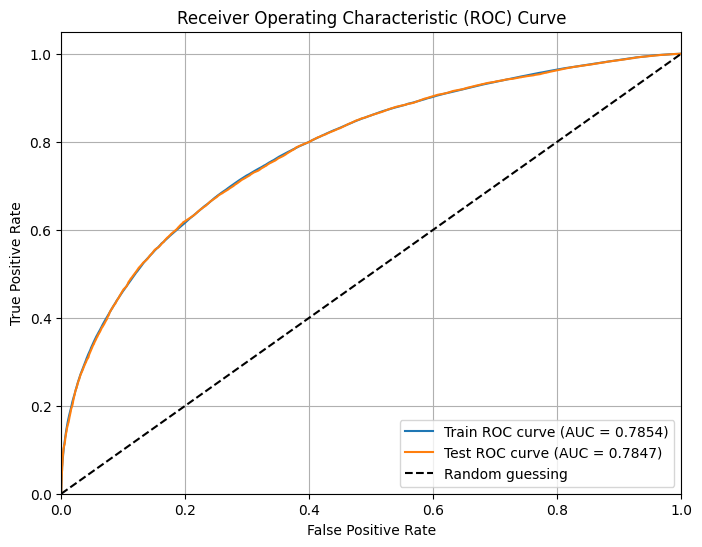

In [20]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, auc
import xgboost
import sklearn
import matplotlib.pyplot as plt

# Check package versions
print(f"XGBoost version: {xgboost.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")

# Load and prepare data
file_path = "15april_cleaned.csv"
df = pd.read_csv(file_path)
target_col = 'Vital status recode (study cutoff used)'
exclude_cols = [target_col, 'COD to site recode ICD-O-3 2023 Revision',
                'SEER cause-specific death classification', 'Survival months']
X = df.drop(columns=exclude_cols)

# Rename columns to replace '<' with 'less_than' to avoid XGBoost error
X = X.rename(columns=lambda col: col.replace('<', 'less_than'))
y = LabelEncoder().fit_transform(df[target_col])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# One-hot encoding
cat_cols = X_train.select_dtypes(include=['object']).columns
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_encoded = pd.DataFrame(encoder.fit_transform(X_train[cat_cols]),
                               columns=encoder.get_feature_names_out(cat_cols),
                               index=X_train.index)
X_test_encoded = pd.DataFrame(encoder.transform(X_test[cat_cols]),
                              columns=encoder.get_feature_names_out(cat_cols),
                              index=X_test.index)
X_train = X_train.drop(columns=cat_cols).join(X_train_encoded)
X_test = X_test.drop(columns=cat_cols).join(X_test_encoded)

# Selected features with '<' replaced by 'less_than'
selected_features = [
    'Age recode with less_than1 year olds_60-64 years',
    'Age recode with less_than1 year olds_65-69 years',
    'Age recode with less_than1 year olds_70-74 years',
    'Age recode with less_than1 year olds_75-79 years',
    'Age recode with less_than1 year olds_80-84 years',
    'Age recode with less_than1 year olds_85+ years',
    'Site recode ICD-O-3 2023 Revision Expanded_Hypopharynx',
    'Site recode ICD-O-3 2023 Revision Expanded_Larynx',
    'Site recode ICD-O-3 2023 Revision Expanded_Major Salivary Glands',
    'Site recode ICD-O-3 2023 Revision Expanded_Oropharynx',
    'Site recode ICD-O-3 2023 Revision Expanded_Tongue Anterior',
    'Grade Pathological (2018+)_2',
    'Grade Pathological (2018+)_9',
    'Grade Pathological (2018+)_Blank(s)',
    'Derived AJCC T, 7th ed (2010-2015)_T1',
    'Derived AJCC T, 7th ed (2010-2015)_T2',
    'Derived AJCC N, 7th ed (2010-2015)_N0',
    'Derived AJCC M, 7th ed (2010-2015)_Blank(s)',
    'Derived AJCC M, 7th ed (2010-2015)_M0',
    '7th Edition Stage Group Recode (2016-2017)_Blank(s)',
    'Derived SEER Cmb Stg Grp (2016-2017)_Blank(s)',
    'Time from diagnosis to treatment in days recode_000',
    'Time from diagnosis to treatment in days recode_Other',
    'Time from diagnosis to treatment in days recode_Unable to calculate'
]

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Initialize XGBoost without use_label_encoder to avoid warning
xgb_model = XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=sum(y_train == 0)/sum(y_train == 1),
    eval_metric='auc',
    early_stopping_rounds=10,
    random_state=42,
    n_jobs=-1
)

# Manual 3-fold cross-validation
print("\n--- Cross-Validation Results ---")
cv = StratifiedKFold(n_splits=3)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_selected, y_train)):
    X_fold_train, y_fold_train = X_train_selected.iloc[train_idx], y_train[train_idx]
    X_fold_val, y_fold_val = X_train_selected.iloc[val_idx], y_train[val_idx]
    
    xgb_model.fit(
        X_fold_train, y_fold_train,
        eval_set=[(X_fold_val, y_fold_val)],
        verbose=False
    )
    
    y_val_proba = xgb_model.predict_proba(X_fold_val)[:, 1]
    fold_auc = roc_auc_score(y_fold_val, y_val_proba)
    cv_scores.append(fold_auc)
    print(f"Fold {fold+1}: {fold_auc:.4f}")

print(f"\nMean ROC-AUC: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

# Final training
print("\n--- Final Training ---")
xgb_model.fit(
    X_train_selected, y_train,
    eval_set=[(X_test_selected, y_test)],
    verbose=False
)

# Training set evaluation
y_train_pred = xgb_model.predict(X_train_selected)
y_train_proba = xgb_model.predict_proba(X_train_selected)[:, 1]
print("\n--- Training Performance ---")
print("Classification Report:")
print(classification_report(y_train, y_train_pred, target_names=['Alive', 'Dead']))
print(f"ROC-AUC: {roc_auc_score(y_train, y_train_proba):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_train, y_train_pred))

# Test set evaluation
y_test_pred = xgb_model.predict(X_test_selected)
y_test_proba = xgb_model.predict_proba(X_test_selected)[:, 1]
print("\n--- Test Performance ---")
print("Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Alive', 'Dead']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_proba):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train_selected.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)
print("\n--- Top 10 Features ---")
print(feature_importance.head(10).to_string(index=False))

# Plot ROC curve
print("\n--- ROC Curve ---")
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
auc_train = auc(fpr_train, tpr_train)
auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f'Train ROC curve (AUC = {auc_train:.4f})')
plt.plot(fpr_test, tpr_test, label=f'Test ROC curve (AUC = {auc_test:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

XGBoost version: 3.0.0
scikit-learn version: 1.6.1

Available encoded feature names:
['Seq_None', 'Seq_Other_Sequence', 'Seq_Surgery_First', 'Seq_Systemic_First', 'Age recode with less_than1 year olds_00 years', 'Age recode with less_than1 year olds_01-04 years', 'Age recode with less_than1 year olds_05-09 years', 'Age recode with less_than1 year olds_10-14 years', 'Age recode with less_than1 year olds_15-19 years', 'Age recode with less_than1 year olds_20-24 years', 'Age recode with less_than1 year olds_25-29 years', 'Age recode with less_than1 year olds_30-34 years', 'Age recode with less_than1 year olds_35-39 years', 'Age recode with less_than1 year olds_40-44 years', 'Age recode with less_than1 year olds_45-49 years', 'Age recode with less_than1 year olds_50-54 years', 'Age recode with less_than1 year olds_55-59 years', 'Age recode with less_than1 year olds_60-64 years', 'Age recode with less_than1 year olds_65-69 years', 'Age recode with less_than1 year olds_70-74 years', 'Age rec

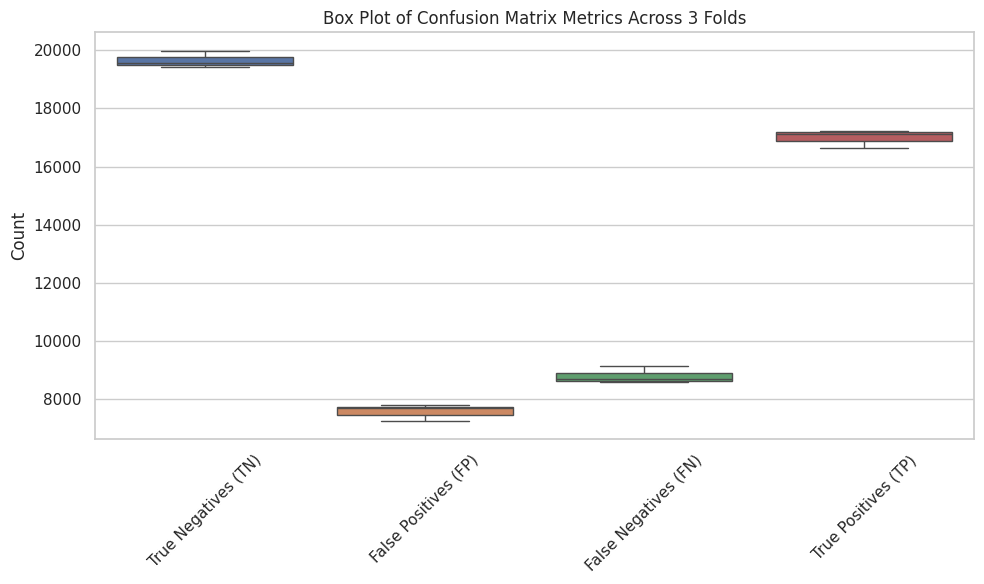


--- Final Training ---

--- Training Performance ---
Classification Report:
              precision    recall  f1-score   support

       Alive       0.69      0.73      0.71     81721
        Dead       0.70      0.66      0.68     77431

    accuracy                           0.69    159152
   macro avg       0.69      0.69      0.69    159152
weighted avg       0.69      0.69      0.69    159152

ROC-AUC: 0.7623
Confusion Matrix:
[[59481 22240]
 [26632 50799]]

--- Test Performance ---
Classification Report:
              precision    recall  f1-score   support

       Alive       0.69      0.73      0.71     20430
        Dead       0.70      0.66      0.68     19358

    accuracy                           0.69     39788
   macro avg       0.69      0.69      0.69     39788
weighted avg       0.69      0.69      0.69     39788

ROC-AUC: 0.7621
Confusion Matrix:
[[14848  5582]
 [ 6559 12799]]

--- Top 10 Features ---
                                                            Featu

/tmp/ipykernel_2724138/125190113.py:196: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')


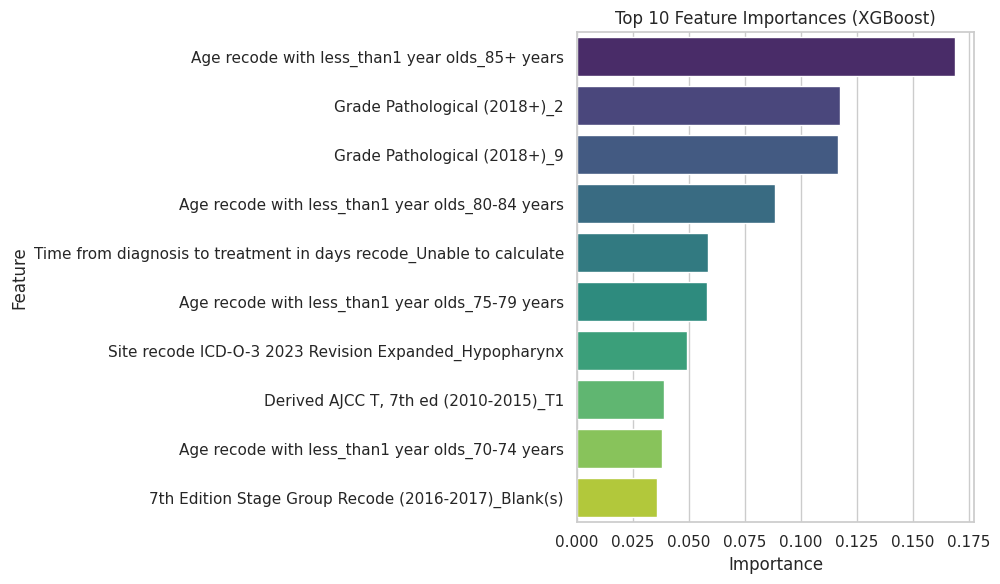


Plots saved in 'eda_plots/confusion_matrix_boxplot.png' and 'eda_plots/top_10_feature_importance.png'.


In [6]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import xgboost
import sklearn

# Function to sanitize filenames
def sanitize_filename(name):
    return re.sub(r'[^\w\s-]', '_', name).strip('_').replace(' ', '_')

# Set style for visualizations
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Create directory for saving plots
plots_dir = 'eda_plots'
os.makedirs(plots_dir, exist_ok=True)

# Check package versions
print(f"XGBoost version: {xgboost.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")

# Load and prepare data
file_path = "15april_cleaned.csv"
df = pd.read_csv(file_path)
target_col = 'Vital status recode (study cutoff used)'
exclude_cols = [target_col, 'COD to site recode ICD-O-3 2023 Revision',
                'SEER cause-specific death classification', 'Survival months']
X = df.drop(columns=exclude_cols)

# Rename columns to replace '<' with 'less_than' to avoid XGBoost error
X = X.rename(columns=lambda col: col.replace('<', 'less_than'))
y = LabelEncoder().fit_transform(df[target_col])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# One-hot encoding
cat_cols = X_train.select_dtypes(include=['object']).columns
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_encoded = pd.DataFrame(encoder.fit_transform(X_train[cat_cols]),
                               columns=encoder.get_feature_names_out(cat_cols),
                               index=X_train.index)
X_test_encoded = pd.DataFrame(encoder.transform(X_test[cat_cols]),
                              columns=encoder.get_feature_names_out(cat_cols),
                              index=X_test.index)
X_train = X_train.drop(columns=cat_cols).join(X_train_encoded)
X_test = X_test.drop(columns=cat_cols).join(X_test_encoded)

# Debug: Print available encoded feature names
print("\nAvailable encoded feature names:")
print(list(X_train.columns))

# Selected features with '<' replaced by 'less_than'
selected_features = [
    'Age recode with less_than1 year olds_60-64 years',
    'Age recode with less_than1 year olds_65-69 years',
    'Age recode with less_than1 year olds_70-74 years',
    'Age recode with less_than1 year olds_75-79 years',
    'Age recode with less_than1 year olds_80-84 years',
    'Age recode with less_than1 year olds_85+ years',
    'Site recode ICD-O-3 2023 Revision Expanded_Hypopharynx',
    'Site recode ICD-O-3 2023 Revision Expanded_Larynx',
    'Site recode ICD-O-3 2023 Revision Expanded_Major Salivary Glands',
    'Site recode ICD-O-3 2023 Revision Expanded_Oropharynx',
    'Site recode ICD-O-3 2023 Revision Expanded_Tongue Anterior',
    'Grade Pathological (2018+)_2',
    'Grade Pathological (2018+)_9',
    'Grade Pathological (2018+)_Blank(s)',  # May need adjustment
    'Derived AJCC T, 7th ed (2010-2015)_T1',
    'Derived AJCC T, 7th ed (2010-2015)_T2',
    'Derived AJCC N, 7th ed (2010-2015)_N0',
    'Derived AJCC M, 7th ed (2010-2015)_Blank(s)',
    'Derived AJCC M, 7th ed (2010-2015)_M0',
    '7th Edition Stage Group Recode (2016-2017)_Blank(s)',
    'Derived SEER Cmb Stg Grp (2016-2017)_Blank(s)',
    'Time from diagnosis to treatment in days recode_000',
    'Time from diagnosis to treatment in days recode_Other',  # May need adjustment
    'Time from diagnosis to treatment in days recode_Unable to calculate'
]

# Filter selected features to those actually present
valid_features = [f for f in selected_features if f in X_train.columns]
missing_features = [f for f in selected_features if f not in X_train.columns]
print(f"\nValid selected features: {len(valid_features)}/{len(selected_features)}")
if missing_features:
    print("Missing features (not in encoded data):", missing_features)

X_train_selected = X_train[valid_features]
X_test_selected = X_test[valid_features]

# Initialize XGBoost
xgb_model = XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=sum(y_train == 0)/sum(y_train == 1),
    eval_metric='auc',
    early_stopping_rounds=10,
    random_state=42,
    n_jobs=-1
)

# Manual 3-fold cross-validation with confusion matrices
print("\n--- Cross-Validation Results ---")
cv = StratifiedKFold(n_splits=3)
cv_scores = []
confusion_matrices = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_selected, y_train)):
    X_fold_train, y_fold_train = X_train_selected.iloc[train_idx], y_train[train_idx]
    X_fold_val, y_fold_val = X_train_selected.iloc[val_idx], y_train[val_idx]
    
    xgb_model.fit(
        X_fold_train, y_fold_train,
        eval_set=[(X_fold_val, y_fold_val)],
        verbose=False
    )
    
    y_val_proba = xgb_model.predict_proba(X_fold_val)[:, 1]
    y_val_pred = xgb_model.predict(X_fold_val)
    fold_auc = roc_auc_score(y_fold_val, y_val_proba)
    cv_scores.append(fold_auc)
    confusion_matrices.append(confusion_matrix(y_fold_val, y_val_pred))
    print(f"Fold {fold+1}: {fold_auc:.4f}")

print(f"\nMean ROC-AUC: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

# Box Plot of Confusion Matrix Metrics
cm_data = {
    'True Negatives (TN)': [cm[0, 0] for cm in confusion_matrices],
    'False Positives (FP)': [cm[0, 1] for cm in confusion_matrices],
    'False Negatives (FN)': [cm[1, 0] for cm in confusion_matrices],
    'True Positives (TP)': [cm[1, 1] for cm in confusion_matrices]
}
cm_df = pd.DataFrame(cm_data)

plt.figure()
sns.boxplot(data=cm_df)
plt.title('Box Plot of Confusion Matrix Metrics Across 3 Folds')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'confusion_matrix_boxplot.png'))
plt.show()
plt.close()

# Final training
print("\n--- Final Training ---")
xgb_model.fit(
    X_train_selected, y_train,
    eval_set=[(X_test_selected, y_test)],
    verbose=False
)

# Training set evaluation
y_train_pred = xgb_model.predict(X_train_selected)
y_train_proba = xgb_model.predict_proba(X_train_selected)[:, 1]
print("\n--- Training Performance ---")
print("Classification Report:")
print(classification_report(y_train, y_train_pred, target_names=['Alive', 'Dead']))
print(f"ROC-AUC: {roc_auc_score(y_train, y_train_proba):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_train, y_train_pred))

# Test set evaluation
y_test_pred = xgb_model.predict(X_test_selected)
y_test_proba = xgb_model.predict_proba(X_test_selected)[:, 1]
print("\n--- Test Performance ---")
print("Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Alive', 'Dead']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_proba):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train_selected.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)
print("\n--- Top 10 Features ---")
print(feature_importance.head(10).to_string(index=False))

# Bar Plot of Top 10 Feature Importances
top_10_features = feature_importance.head(10)
plt.figure()
sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')
plt.title('Top 10 Feature Importances (XGBoost)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'top_10_feature_importance.png'))
plt.show()
plt.close()

print(f"\nPlots saved in '{plots_dir}/confusion_matrix_boxplot.png' and '{plots_dir}/top_10_feature_importance.png'.")

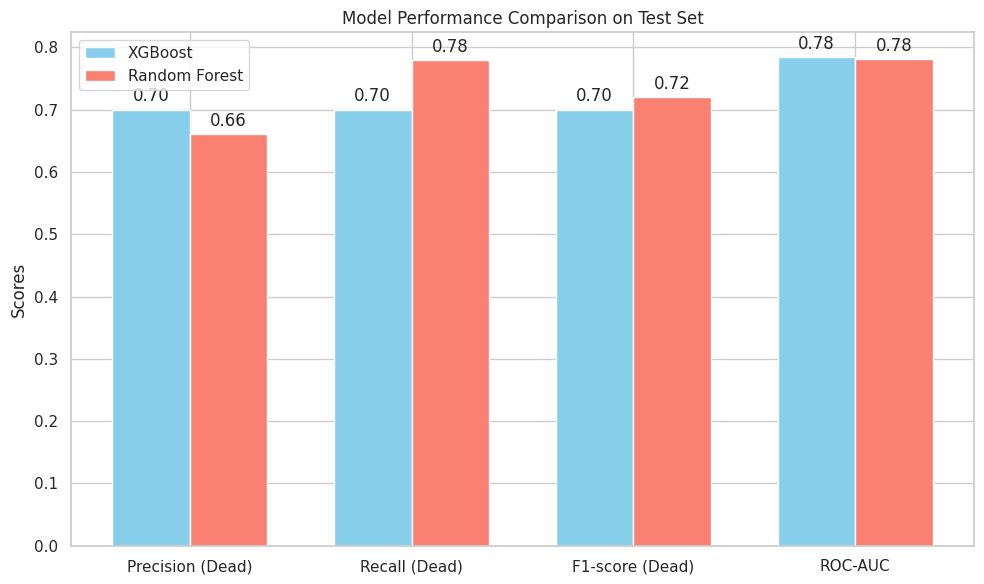

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Define the metrics and their values for both models
metrics = ['Precision (Dead)', 'Recall (Dead)', 'F1-score (Dead)', 'ROC-AUC']
xgb_values = [0.70, 0.70, 0.70, 0.7847]  # XGBoost metrics
rf_values = [0.66, 0.78, 0.72, 0.7814]   # Random Forest metrics

# Set up the bar positions
x = np.arange(len(metrics))  # the label locations
width = 0.35  # the width of the bars

# Create the bar graph
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, xgb_values, width, label='XGBoost', color='skyblue')
rects2 = ax.bar(x + width/2, rf_values, width, label='Random Forest', color='salmon')

# Customize the plot
ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison on Test Set')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Function to add labels on top of the bars
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

# Add labels to the bars
add_labels(rects1)
add_labels(rects2)

# Adjust layout and save the plot
plt.tight_layout()
plt.savefig('model_comparison_bar.png')

In [ ]:
(check assumption)(features logical back with article)

In [ ]:
Project ends

In [ ]:
Hyper parameter tuning(compare both model